# Evil Twin Attack Detection — ML Pipeline (from CSV)

Notebook for training Evil Twin attack classification models based on a pre-built `rssi_raw.csv` dataset (without querying InfluxDB).

## 1. Imports & Configuration

In [47]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 17,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.dpi': 320,
    'savefig.dpi': 320,
})

In [48]:
from pathlib import Path

def _find_repo_root(marker="data/rssi_raw.csv"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not locate {marker} from {p}")

DATASET_PATH = _find_repo_root() / "data" / "rssi_raw.csv"

ANTENNA_MAP = {
    "none": 0,
    "Alfa ARS-N05": 1,
    "Alfa ARS-N19": 2,
    "Alfa APA-M25": 3,
    "AOSIYANT Yagi 16dBi": 4,
    "Logperiodic": 5,
    "Alfa APA-M04": 6,
}
ANTENNA_NAMES = {v: k for k, v in ANTENNA_MAP.items()}

## 2. Load Dataset

In [49]:
raw = pd.read_csv(DATASET_PATH, parse_dates=["time"])

print(f"Raw records: {len(raw)}")
print(f"Time range: {raw['time'].min()} → {raw['time'].max()}")
print(f"\nAttack distribution (raw readings):\n{raw['attack'].value_counts().to_string()}")
print(f"\nPoint distribution (raw readings):\n{raw['point'].value_counts().sort_index().to_string()}")
print(f"\nAntenna distribution (raw readings):")
for code_val, count in raw["antenna"].value_counts().sort_index().items():
    print(f"  {code_val} ({ANTENNA_NAMES[code_val]}): {count}")

raw.head(20)

Raw records: 5758
Time range: 2026-05-23 14:30:01.246000+03:00 → 2026-05-23 17:30:31.444000+03:00

Attack distribution (raw readings):
0    4266
1    1492

Point distribution (raw readings):
0    4266
1     184
2     187
3     201
4     187
5     183
6     183
7     180
8     187

Antenna distribution (raw readings):
  0 (none): 4266
  1 (Alfa ARS-N05): 238
  2 (Alfa ARS-N19): 243
  3 (Alfa APA-M25): 252
  4 (AOSIYANT Yagi 16dBi): 267
  5 (Logperiodic): 239
  6 (Alfa APA-M04): 253


,time,deviceID,value,point,attack,antenna
0,2026-05-23 14:30:01.246000+03:00,sensor_4,-59,0,0,0
1,2026-05-23 14:30:03.330000+03:00,sensor_2,-54,0,0,0
2,2026-05-23 14:30:05.457000+03:00,sensor_3,-62,0,0,0
3,2026-05-23 14:30:05.556000+03:00,sensor_1,-56,0,0,0
4,2026-05-23 14:30:08.367000+03:00,sensor_4,-60,0,0,0
5,2026-05-23 14:30:10.602000+03:00,sensor_2,-54,0,0,0
6,2026-05-23 14:30:12.581000+03:00,sensor_3,-64,0,0,0
7,2026-05-23 14:30:12.677000+03:00,sensor_1,-55,0,0,0
8,2026-05-23 14:30:15.589000+03:00,sensor_4,-60,0,0,0
9,2026-05-23 14:30:17.774000+03:00,sensor_2,-53,0,0,0


## 3. RSSI Visualization

### 3.1 Baseline (no attack)

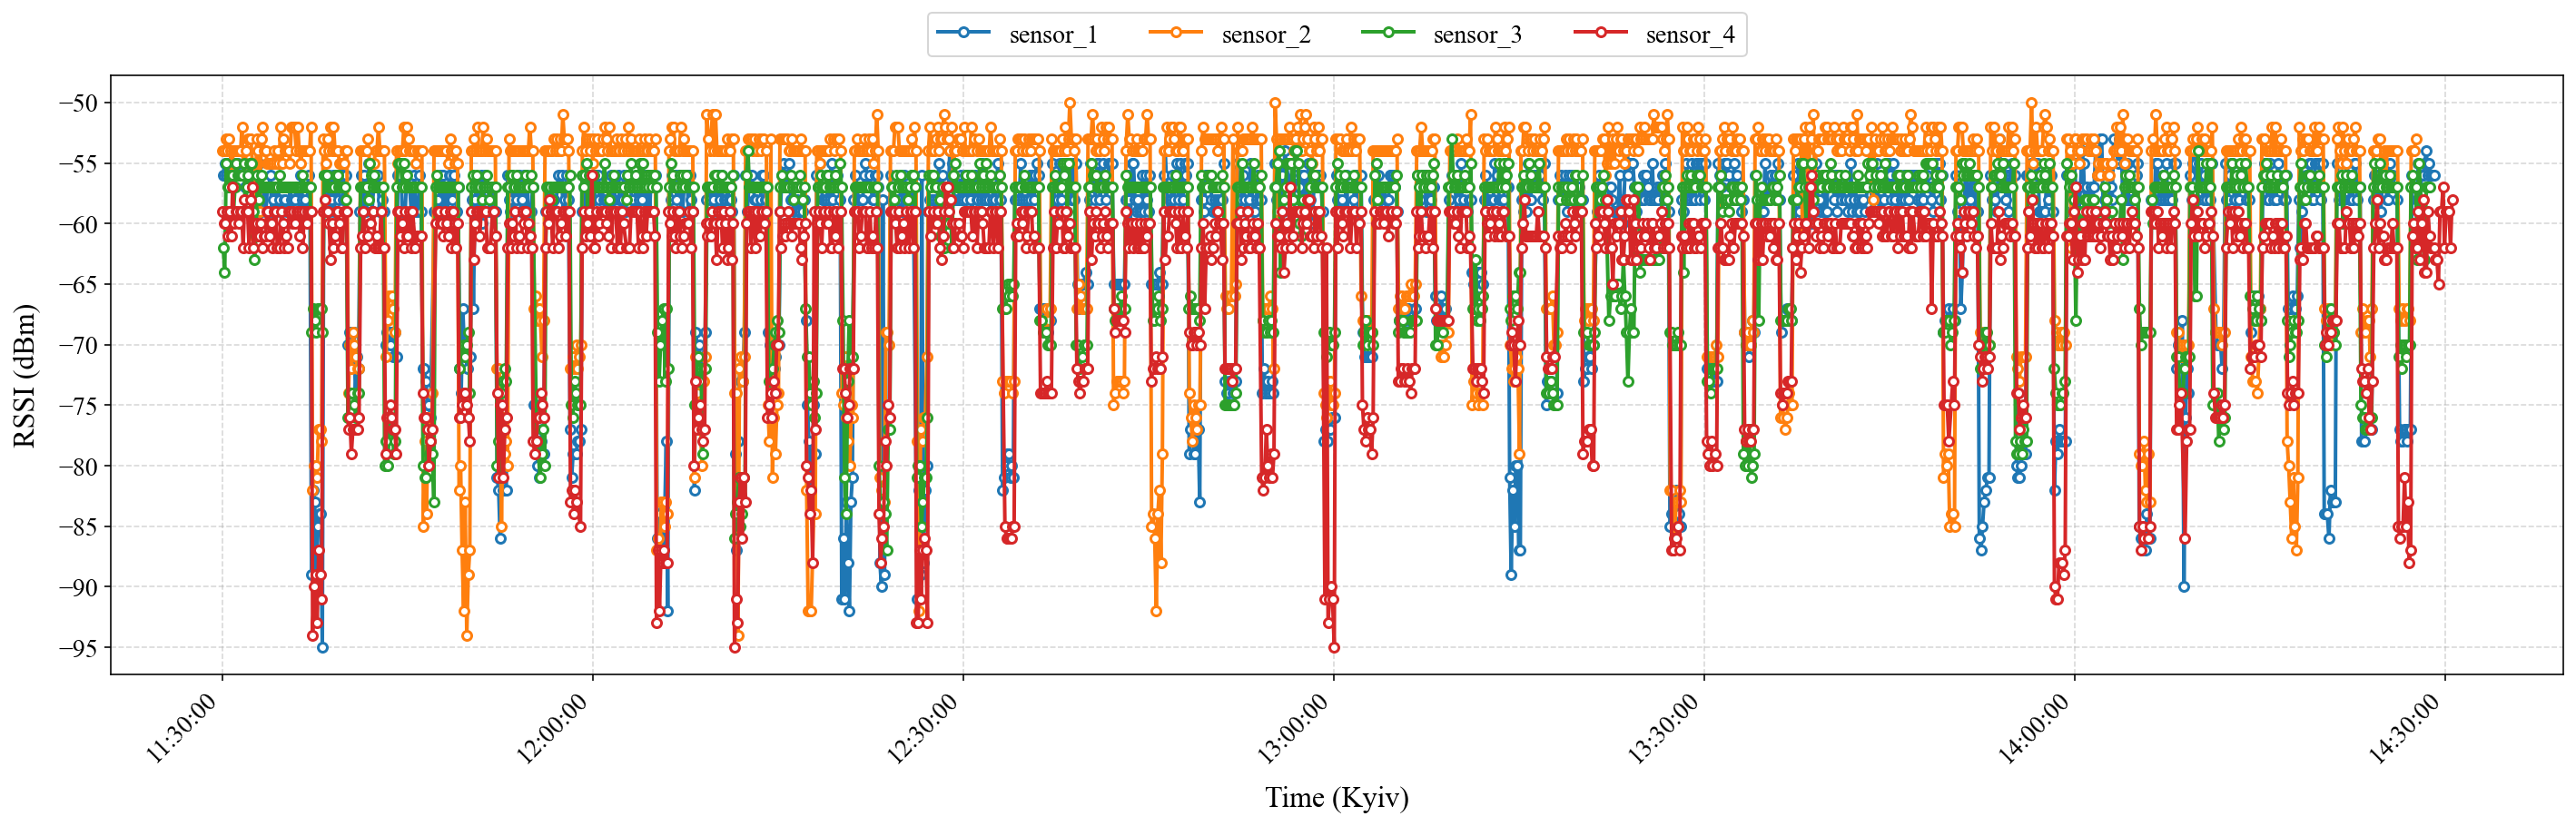

In [50]:
fig, ax = plt.subplots(figsize=(20, 7))

for device in sorted(raw["deviceID"].unique()):
    dev_df = raw[raw["deviceID"] == device]
    ax.plot(dev_df["time"], dev_df["value"], label=device, linewidth=2,
            marker='o', markersize=5, markerfacecolor='white', markeredgewidth=1.5)

ax.yaxis.set_major_locator(plt.MultipleLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
ax.set_xlabel("Time (Kyiv)", labelpad=10)
ax.set_ylabel("RSSI (dBm)", labelpad=10)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=4)
ax.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### 3.2 Attack windows

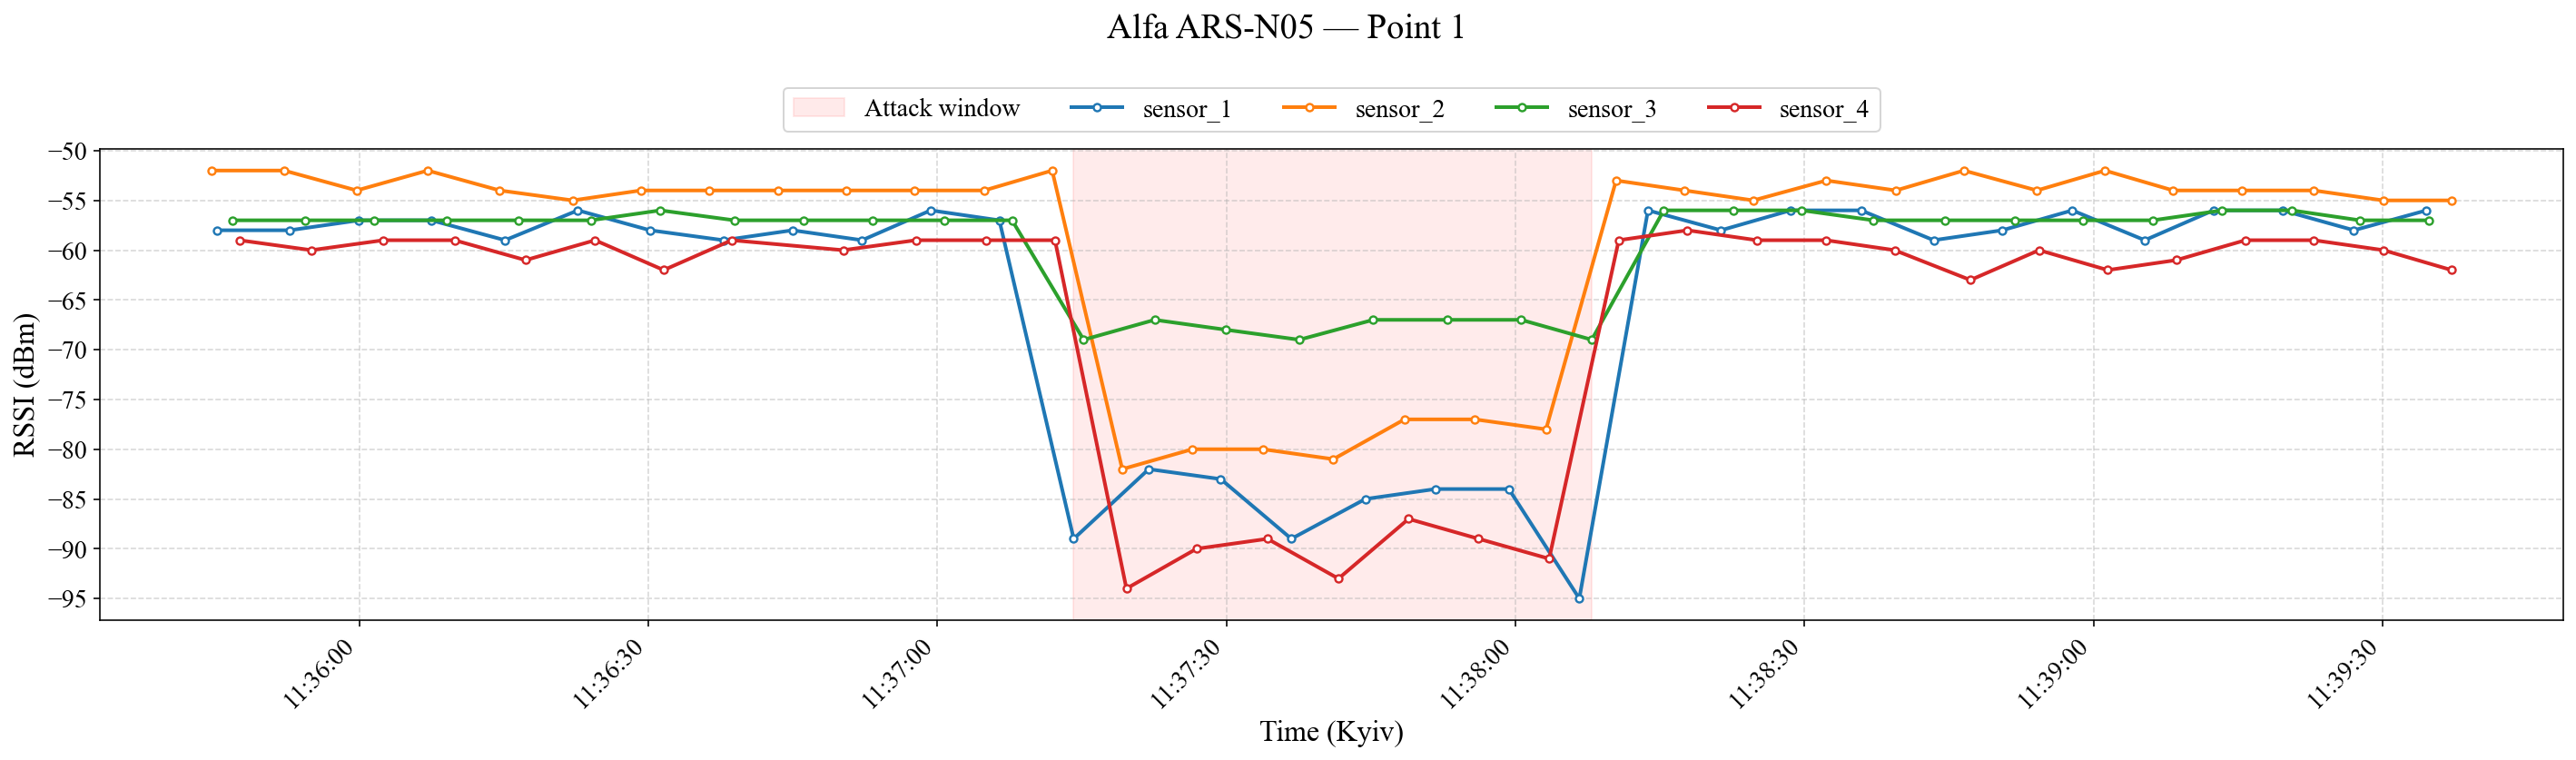

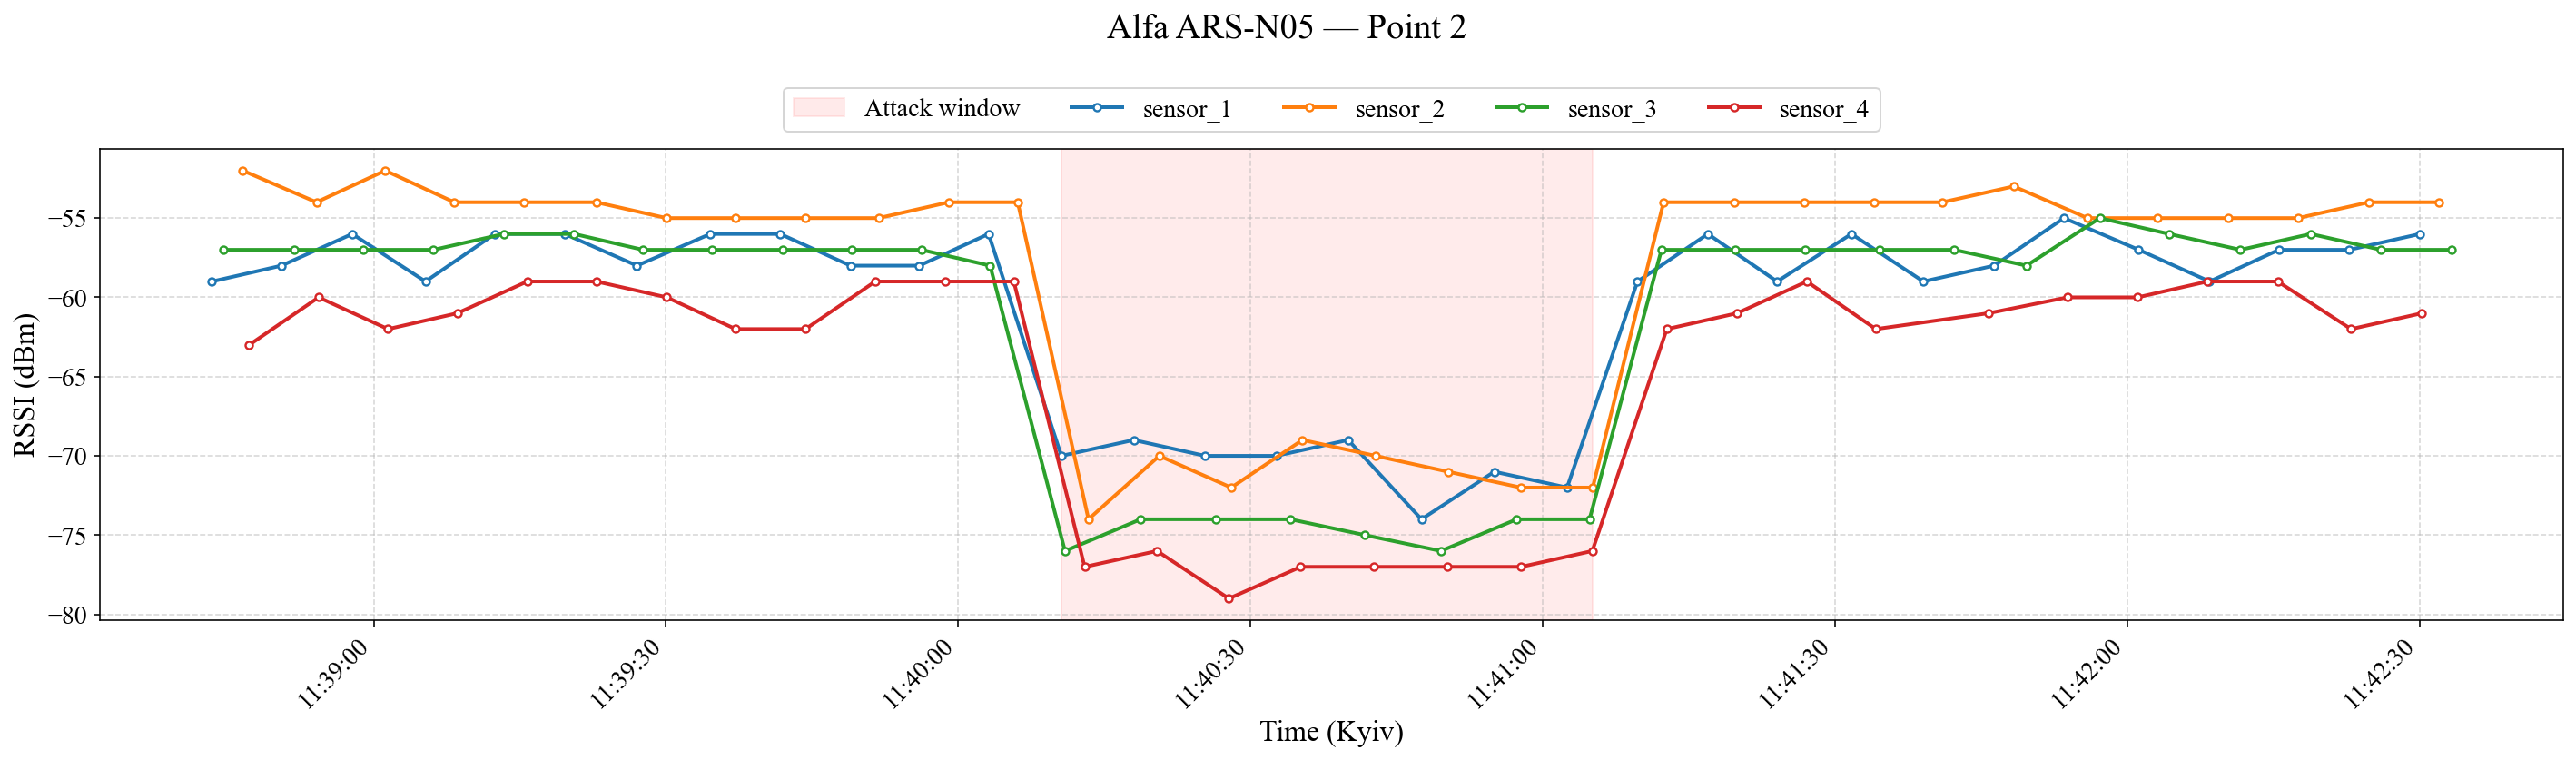

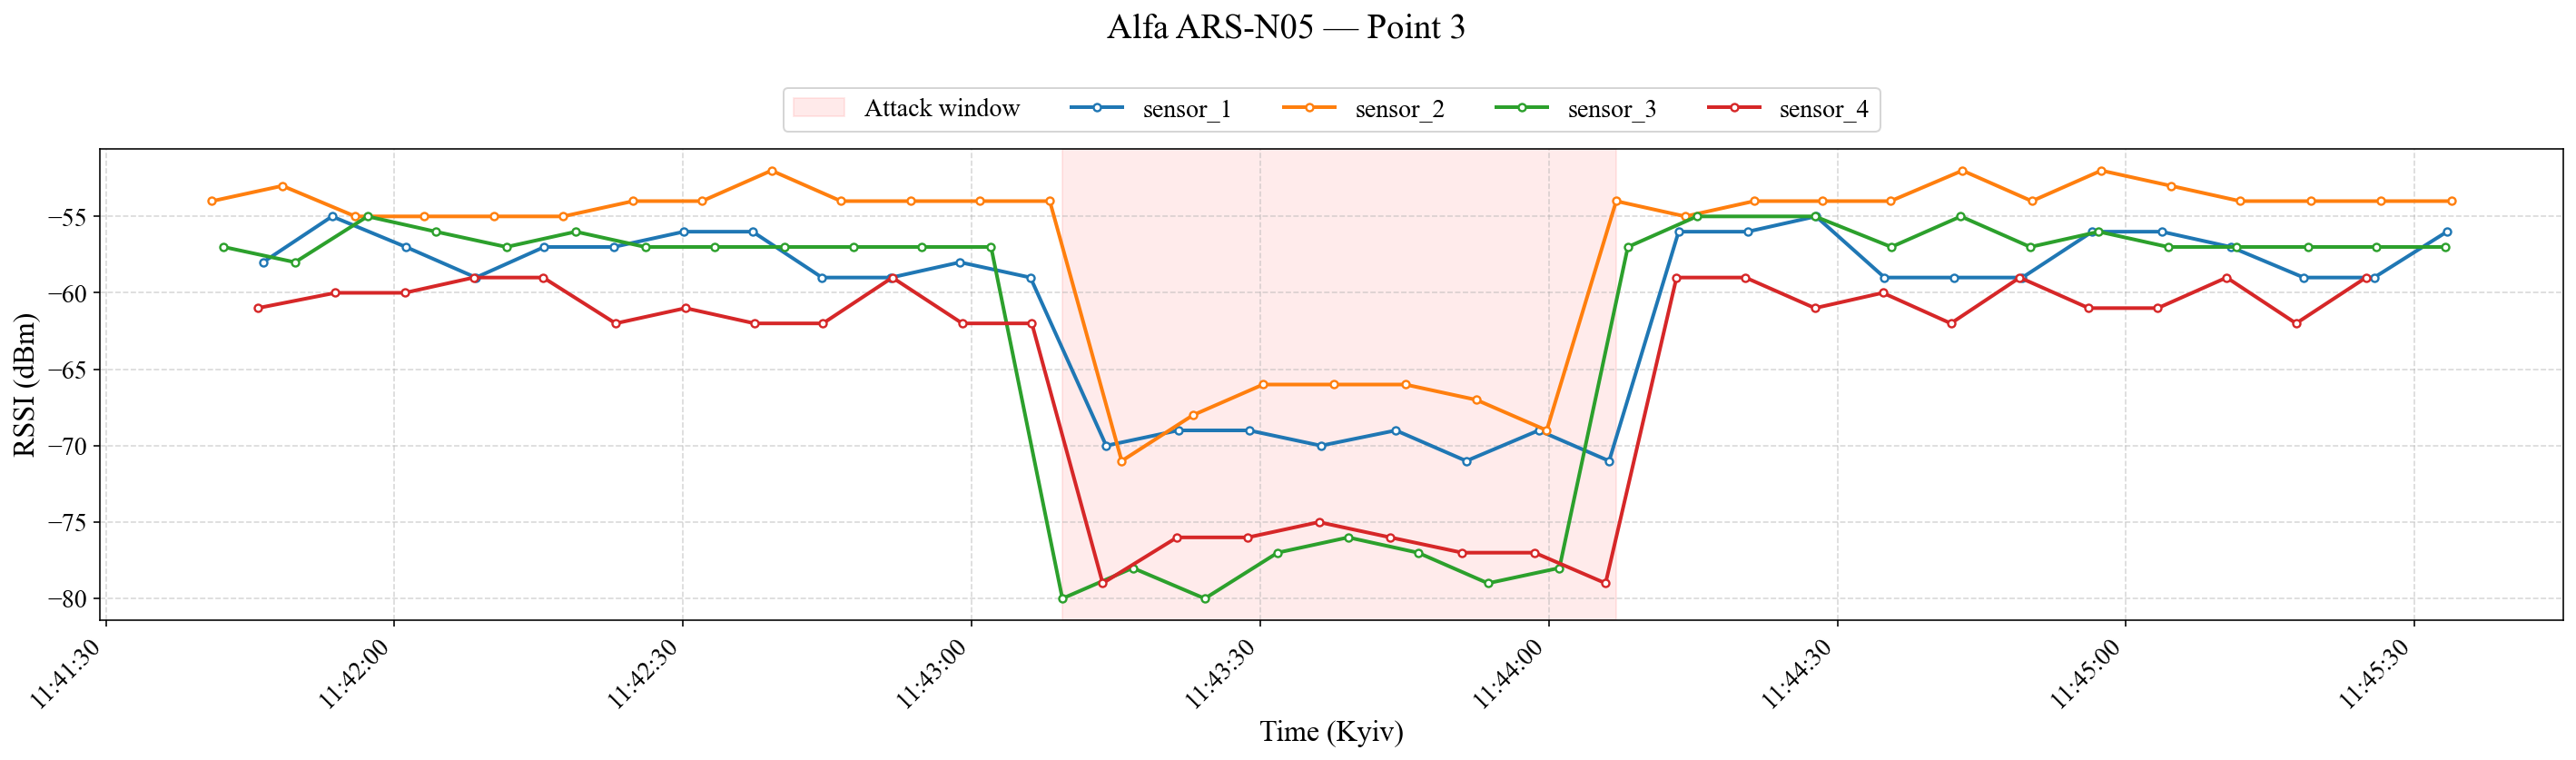

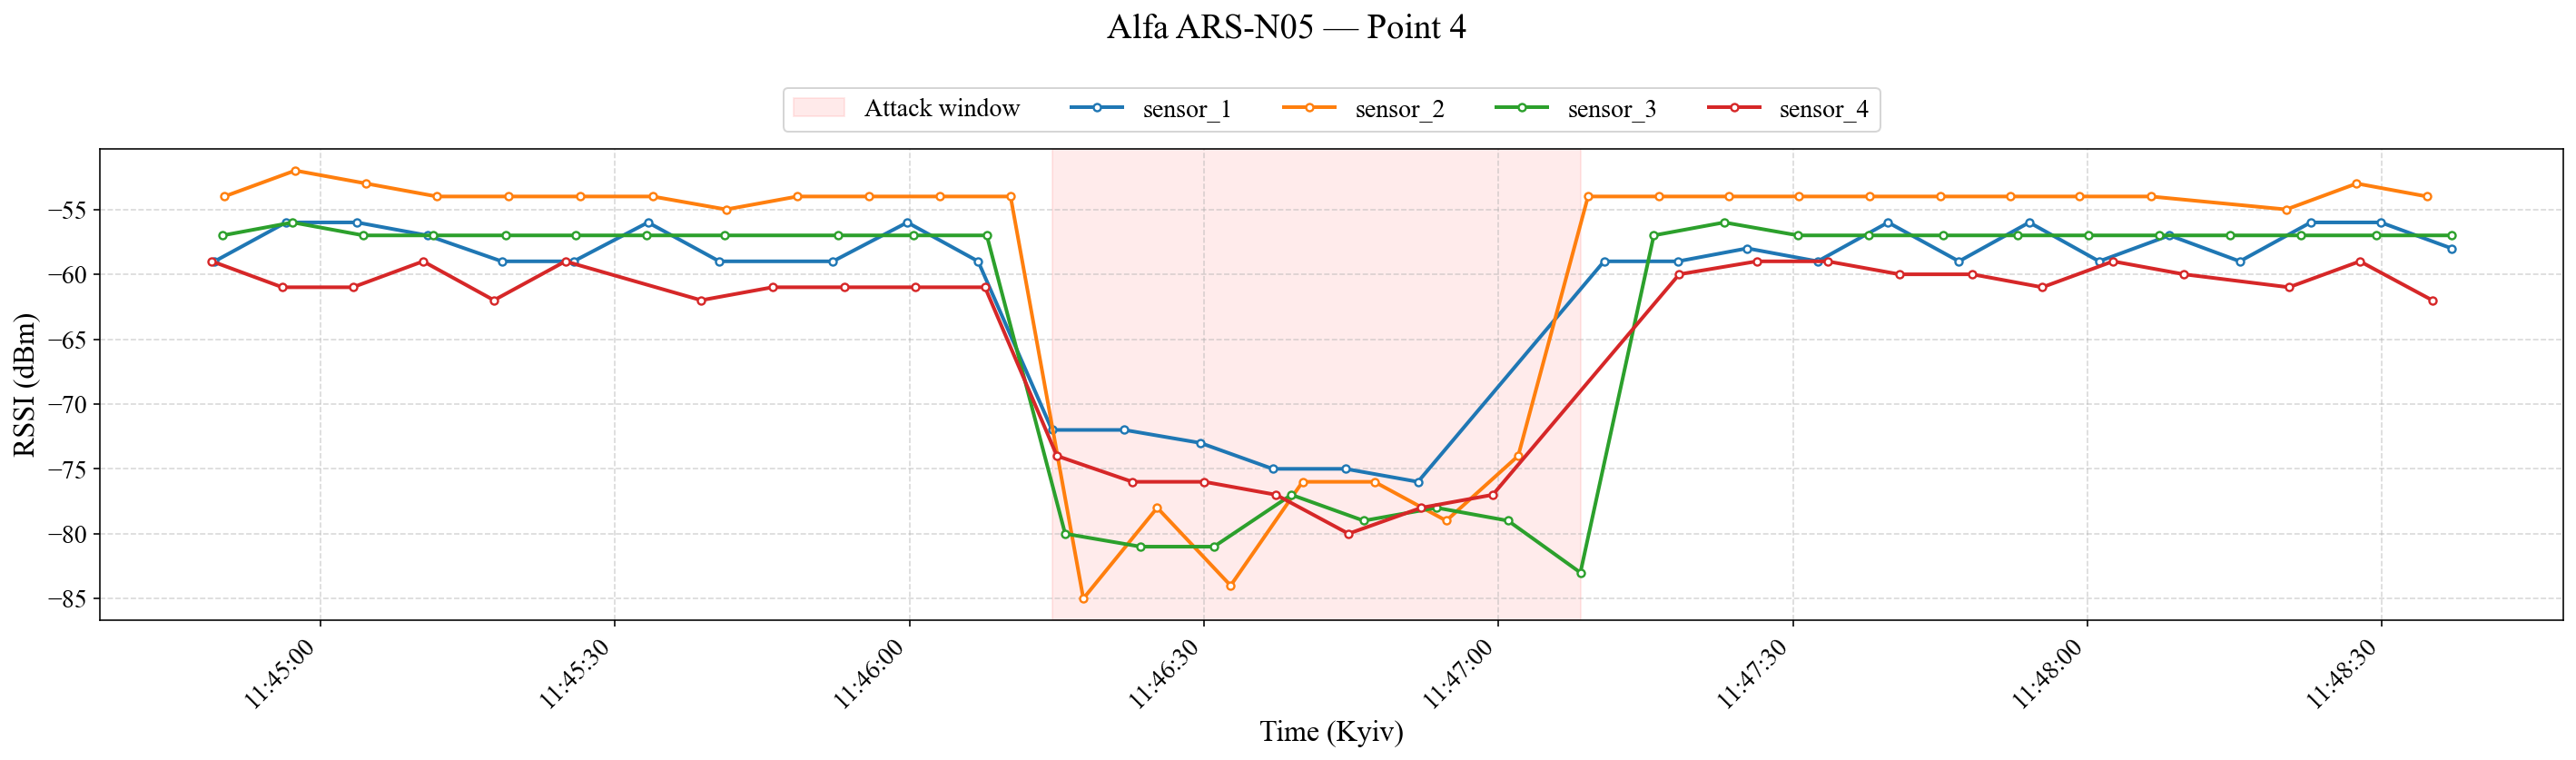

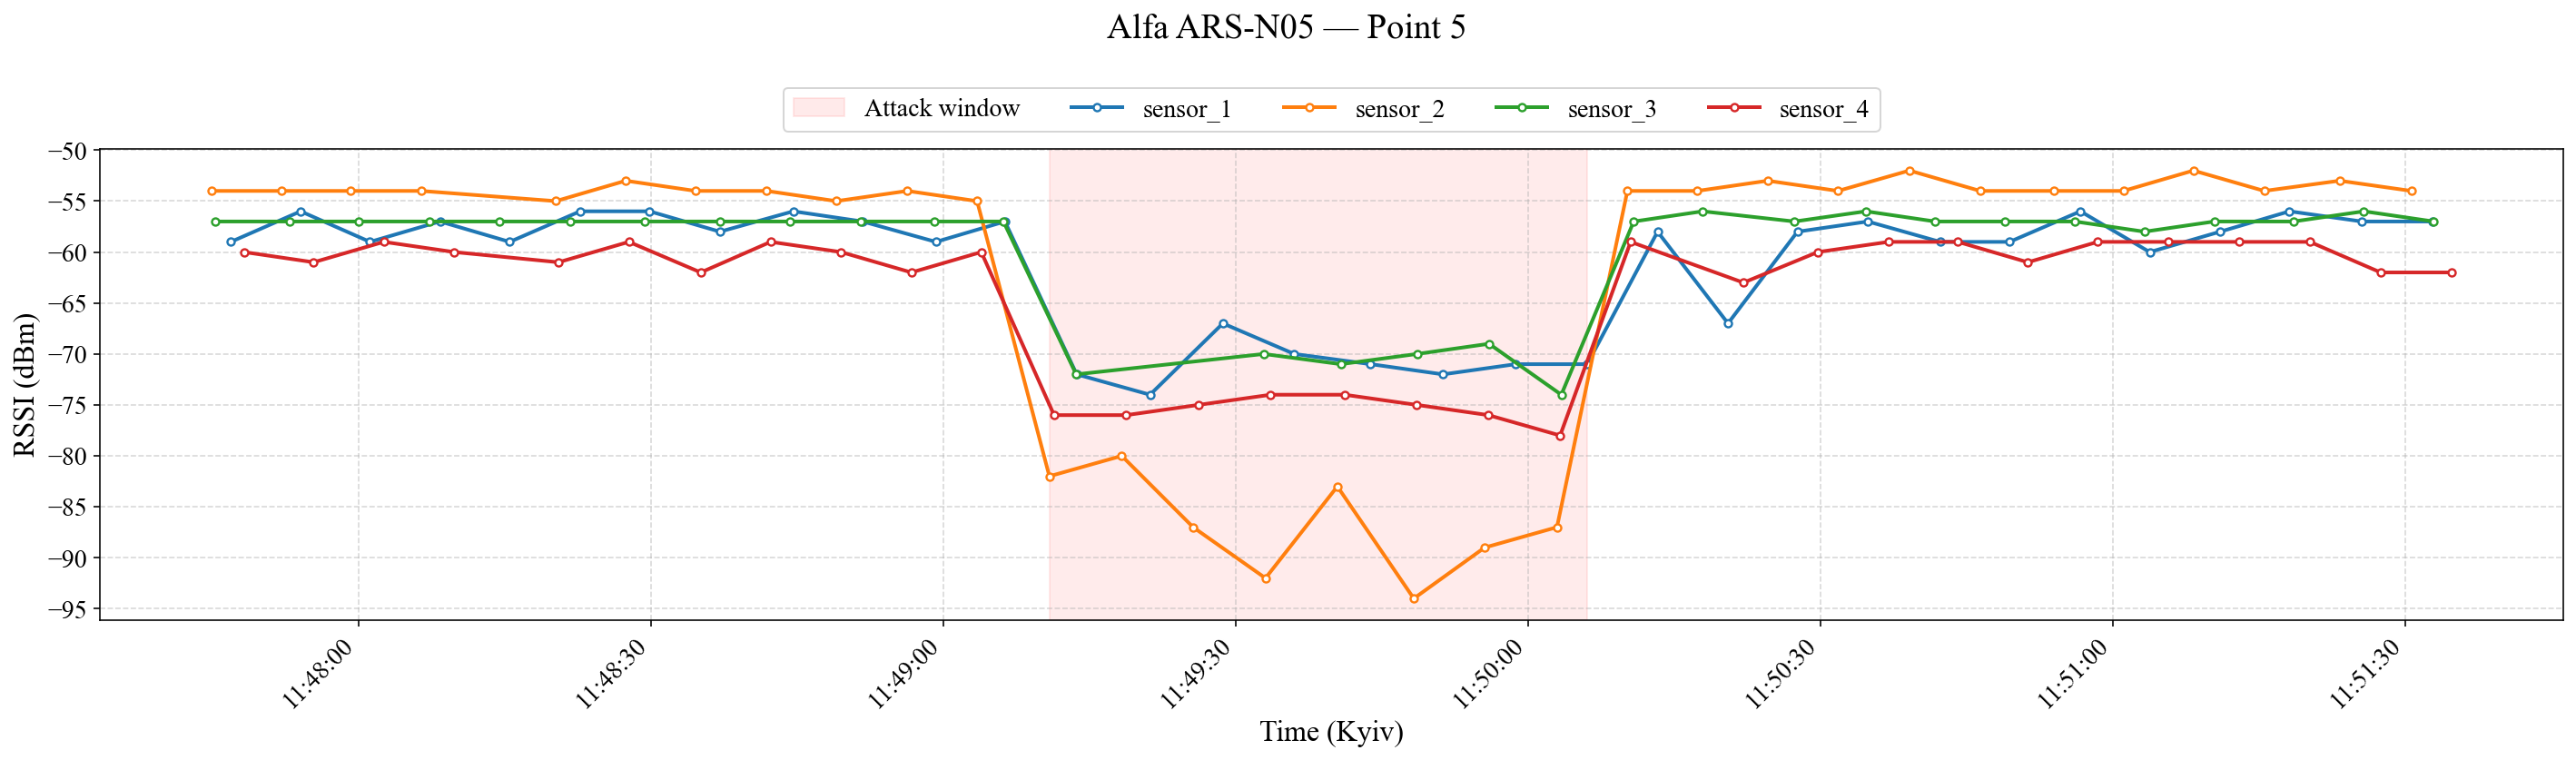

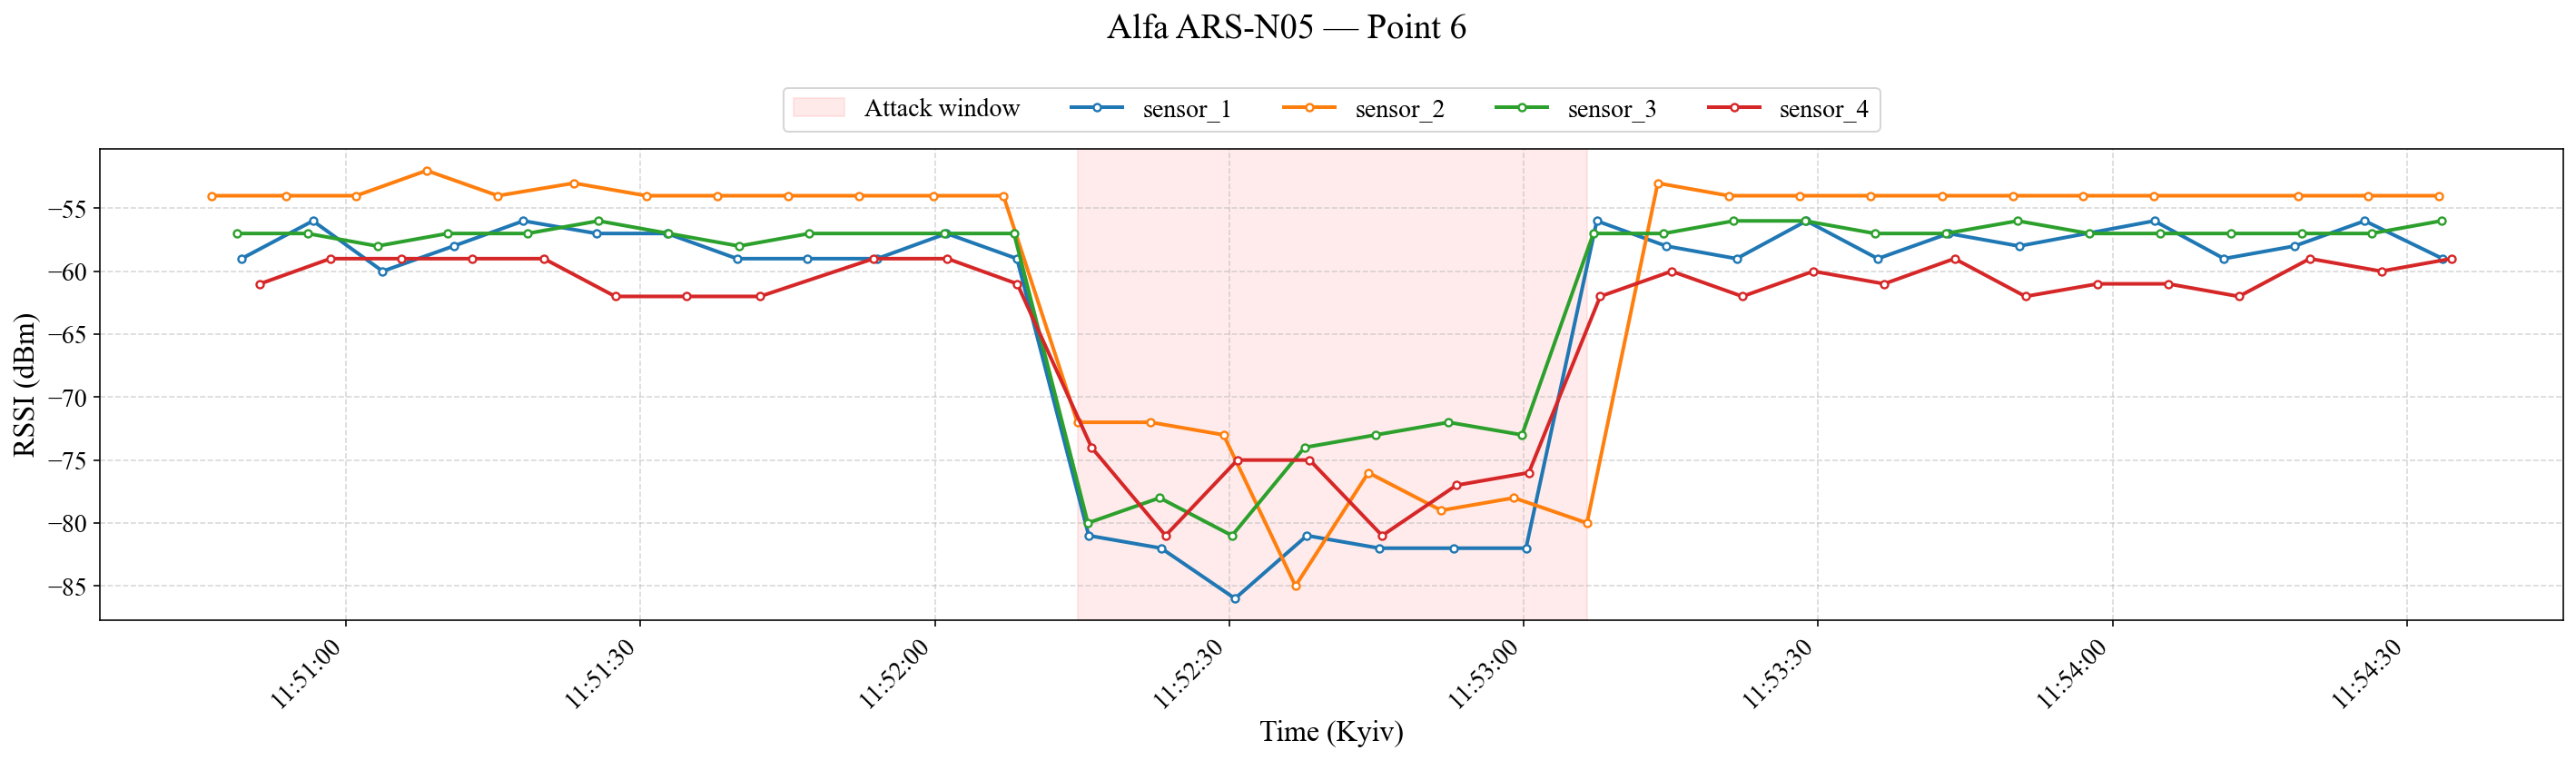

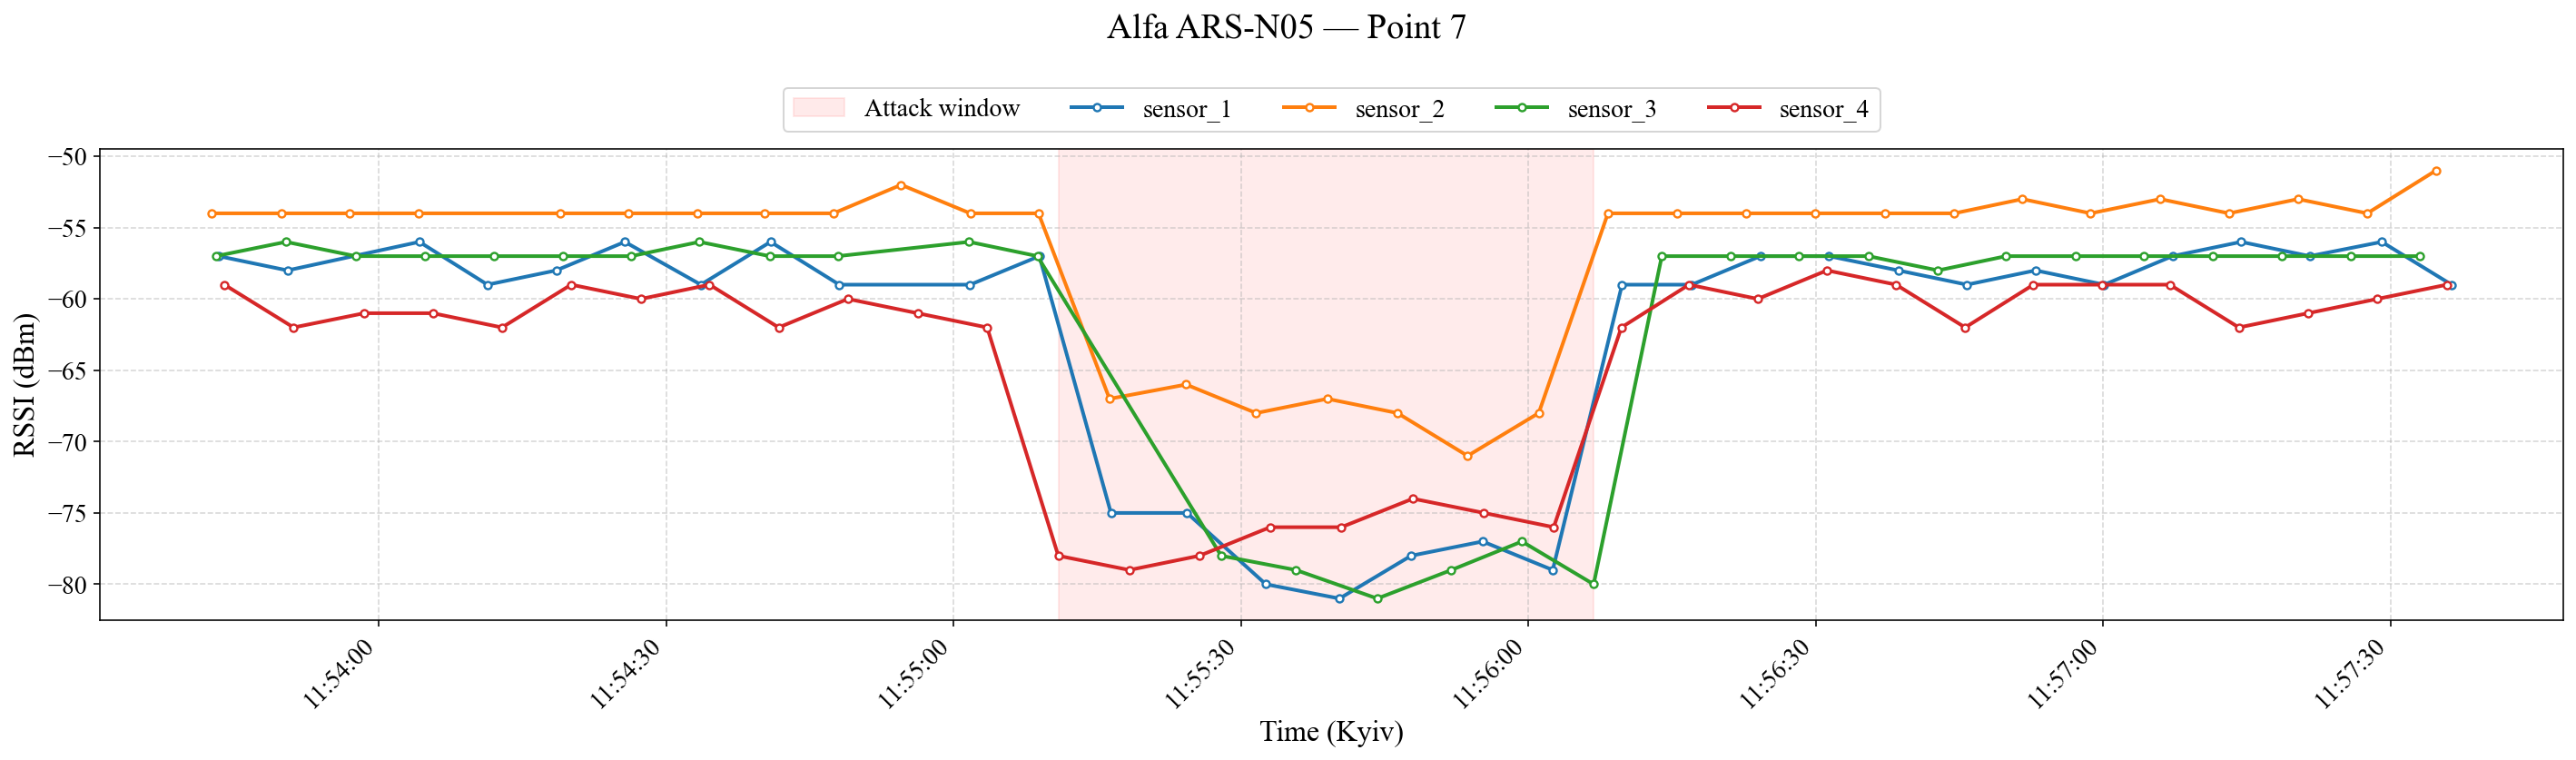

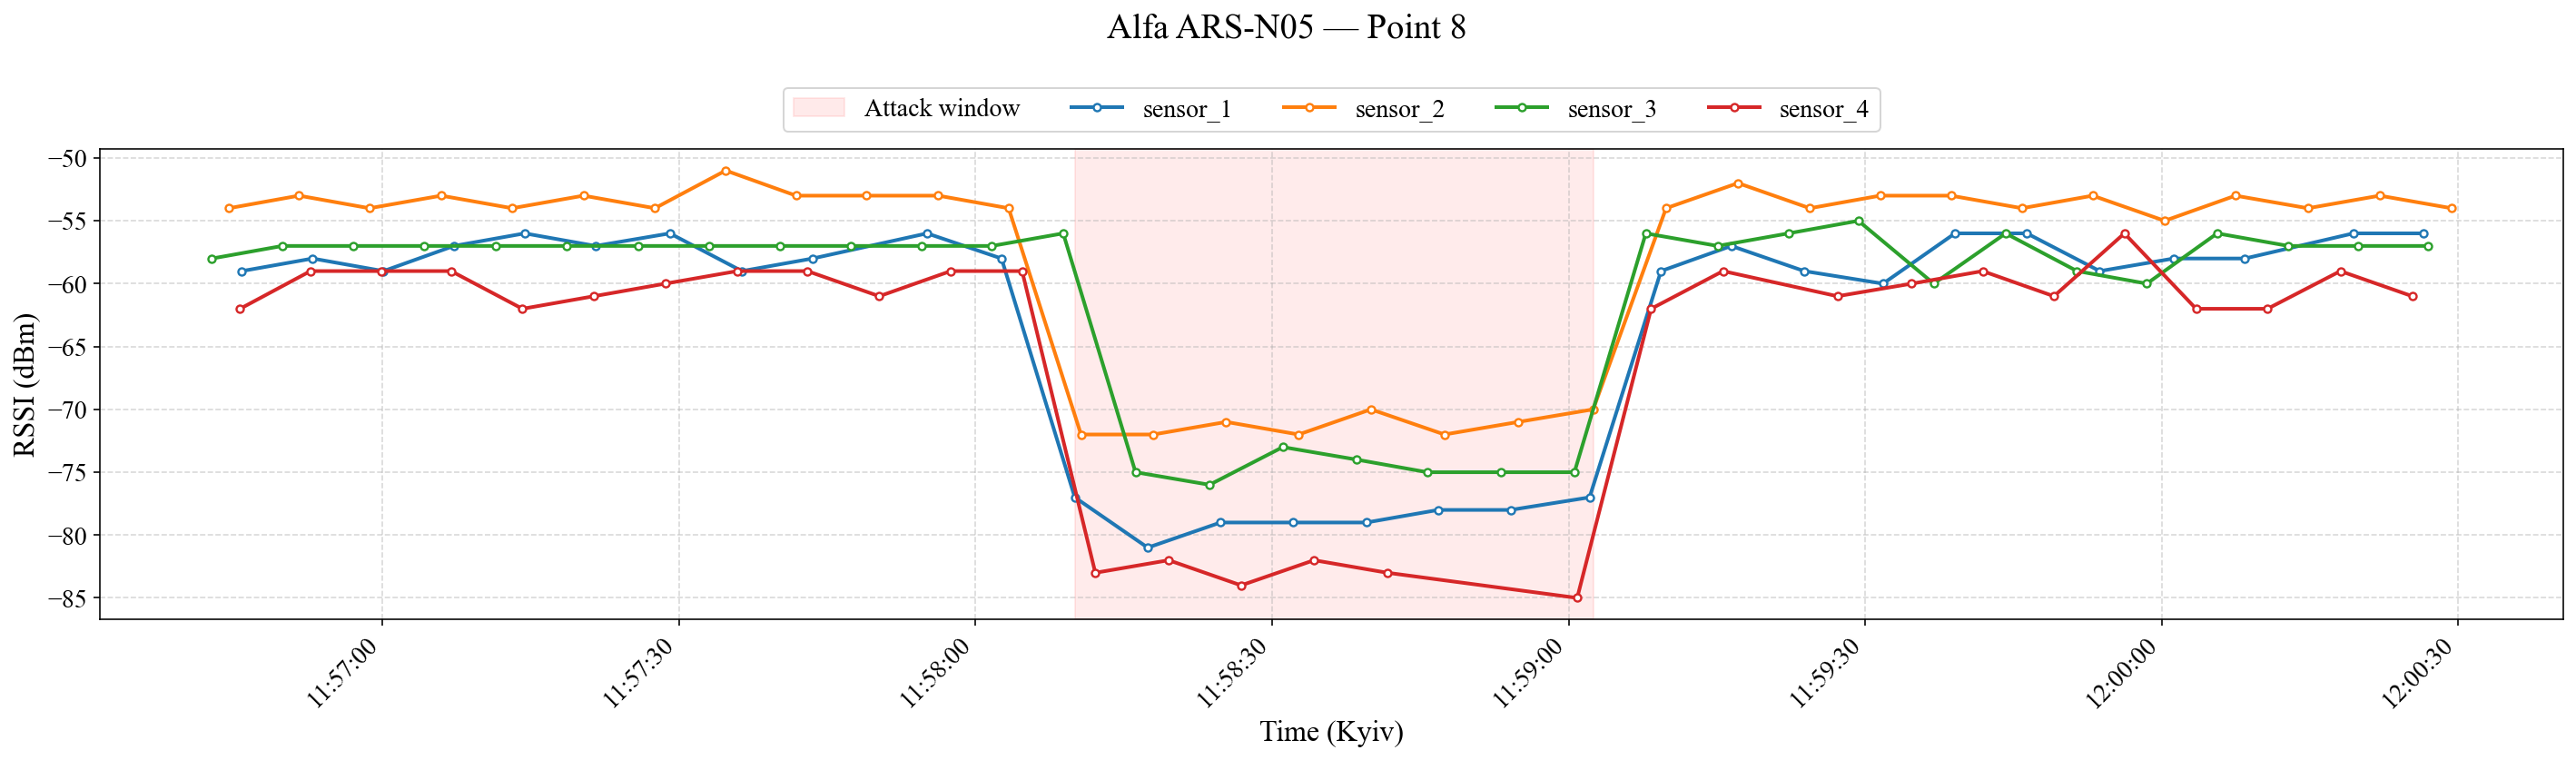

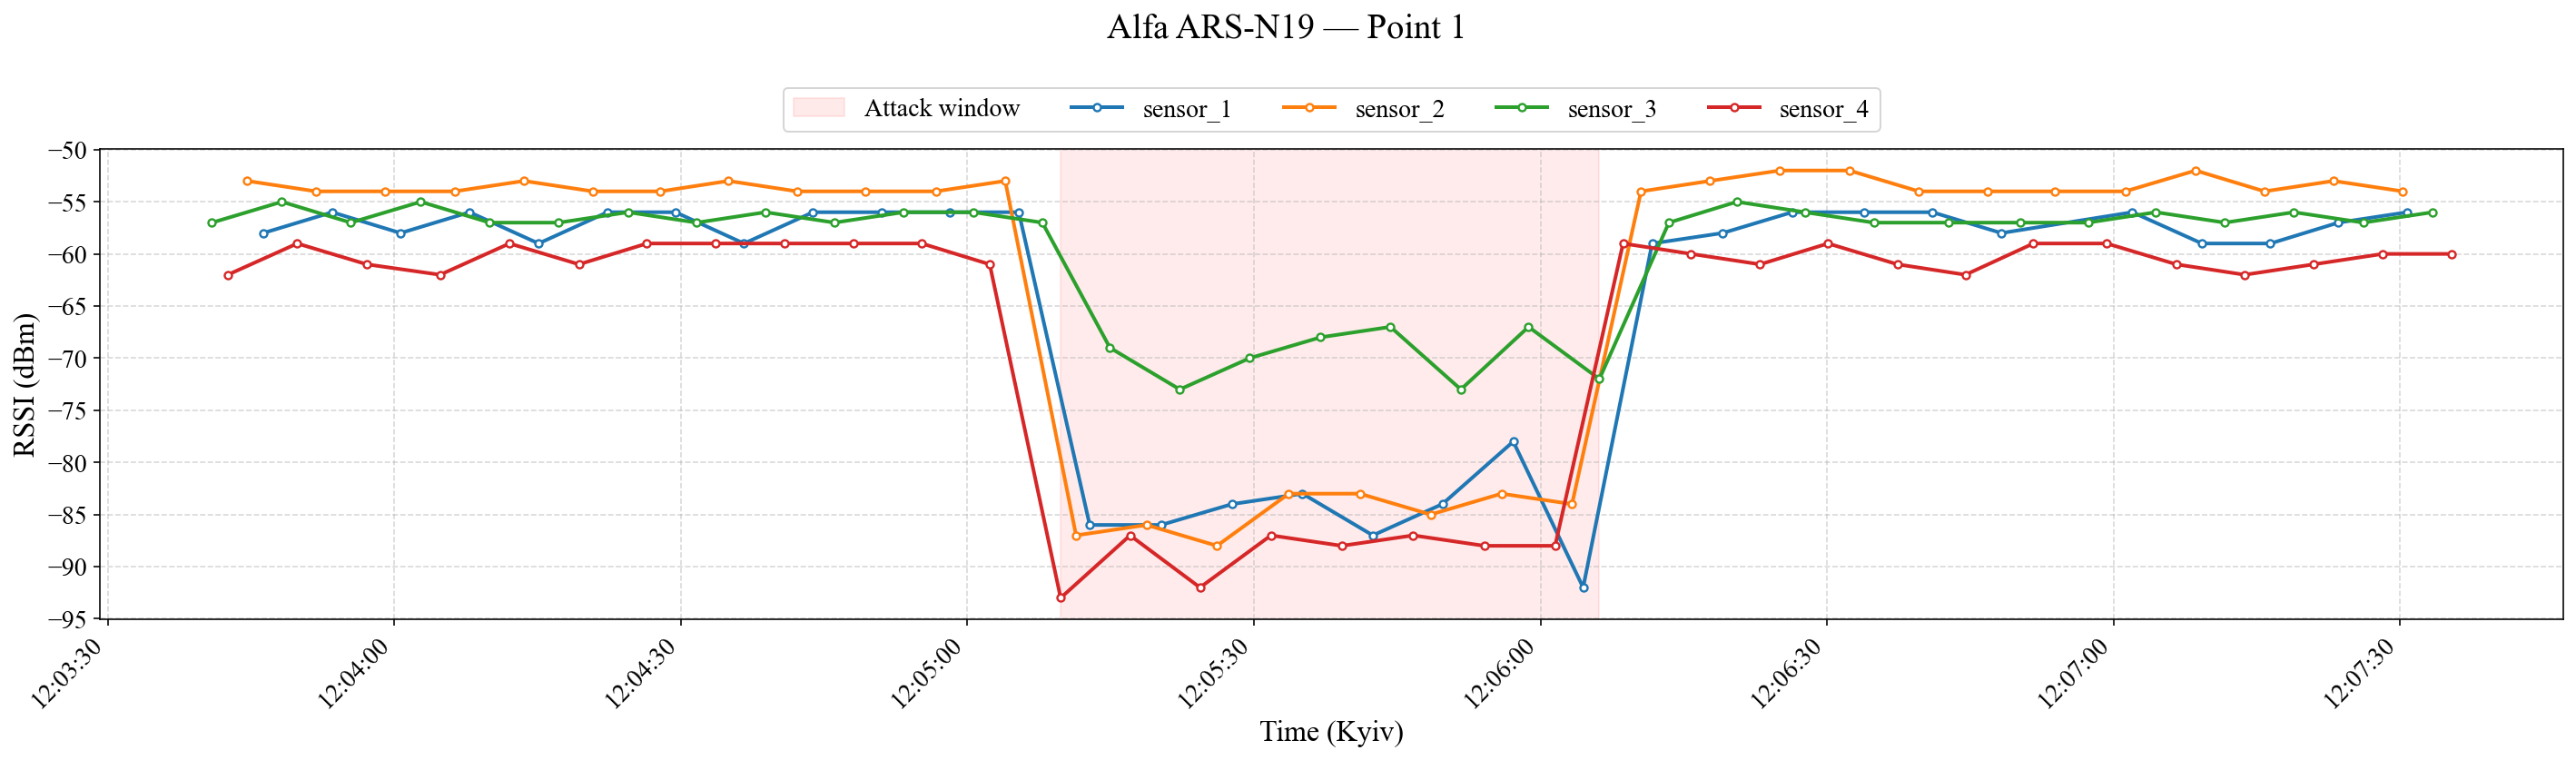

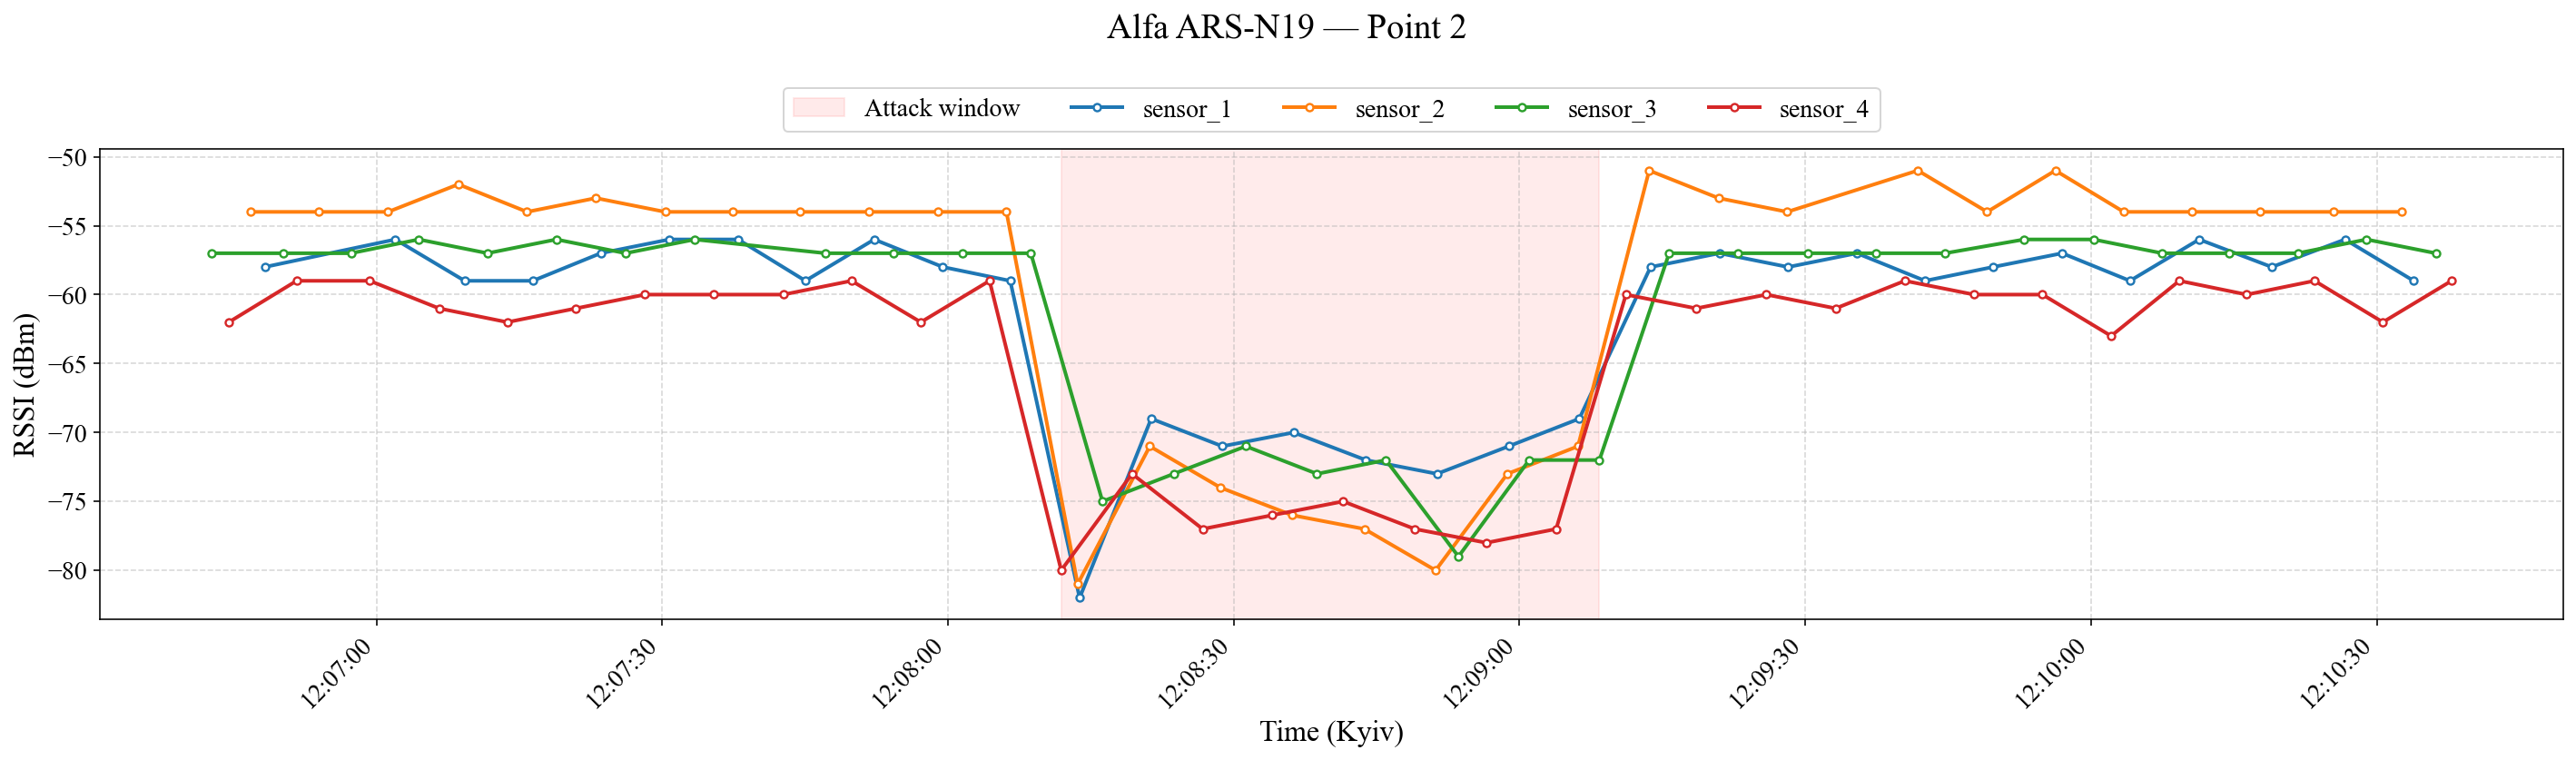

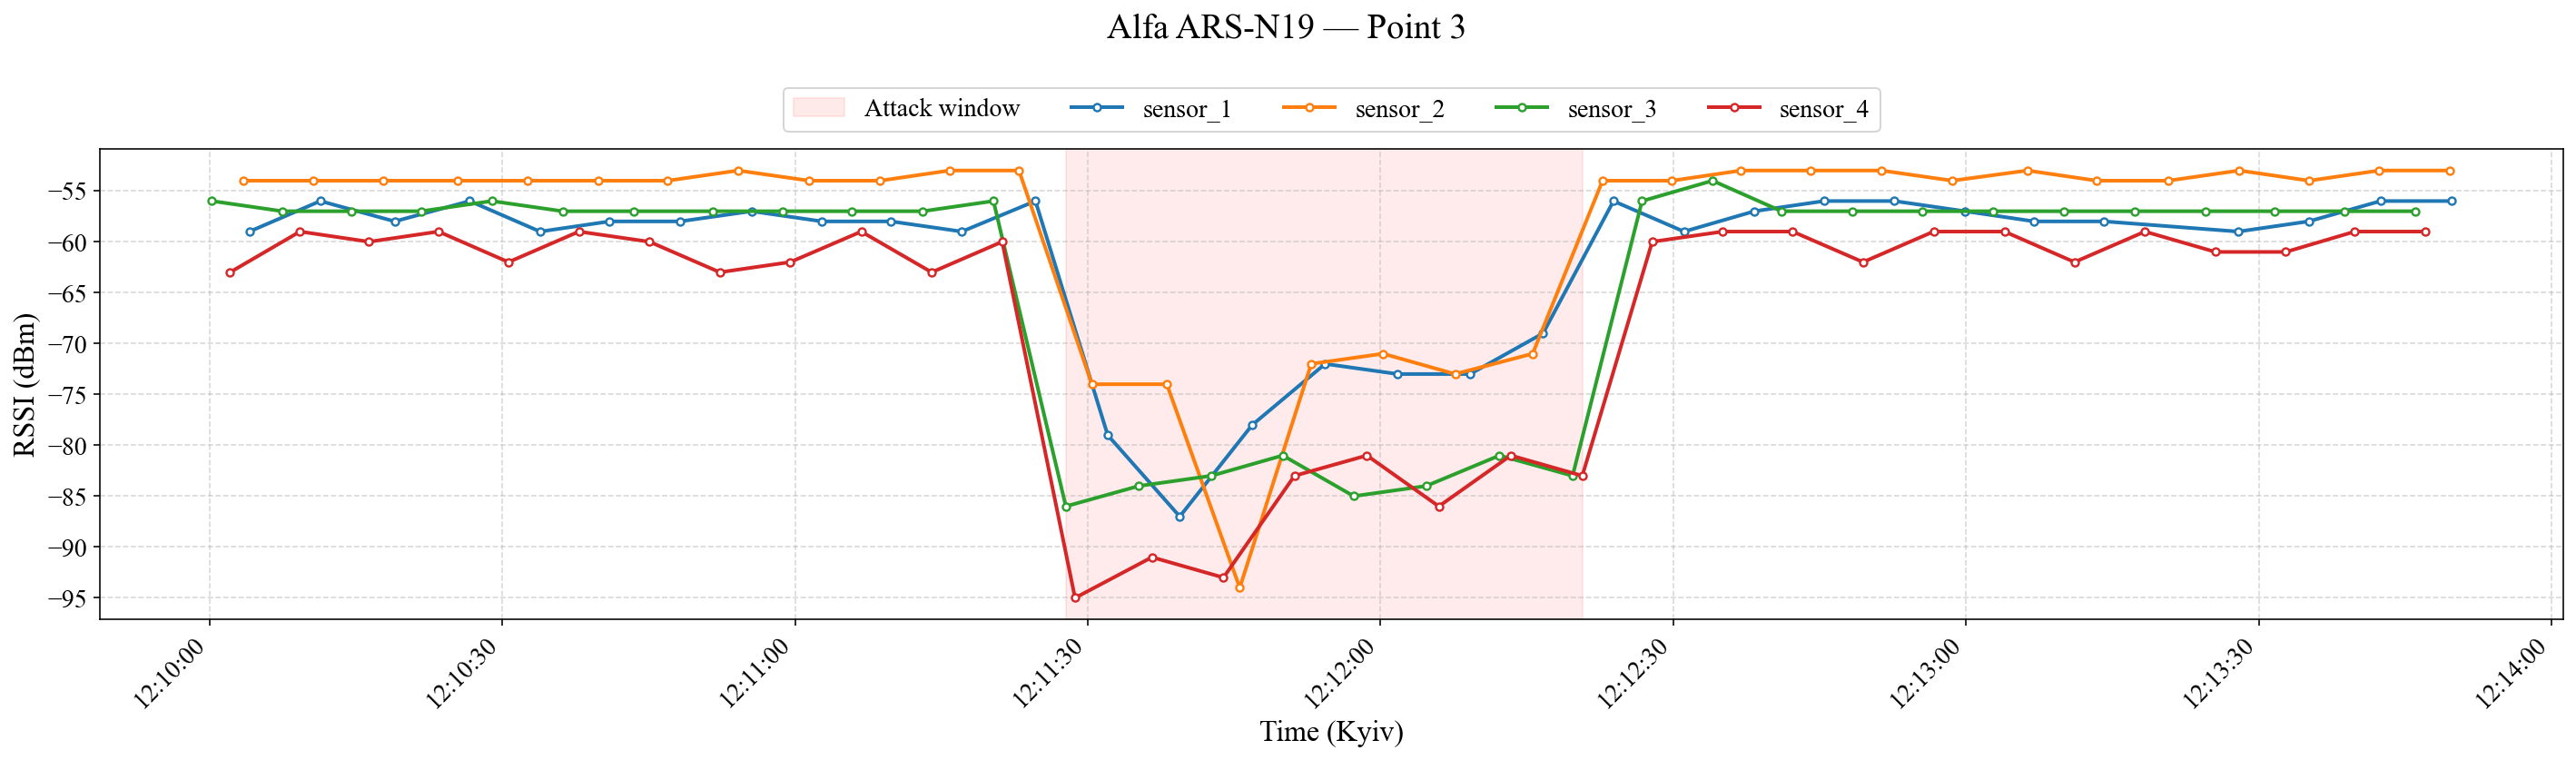

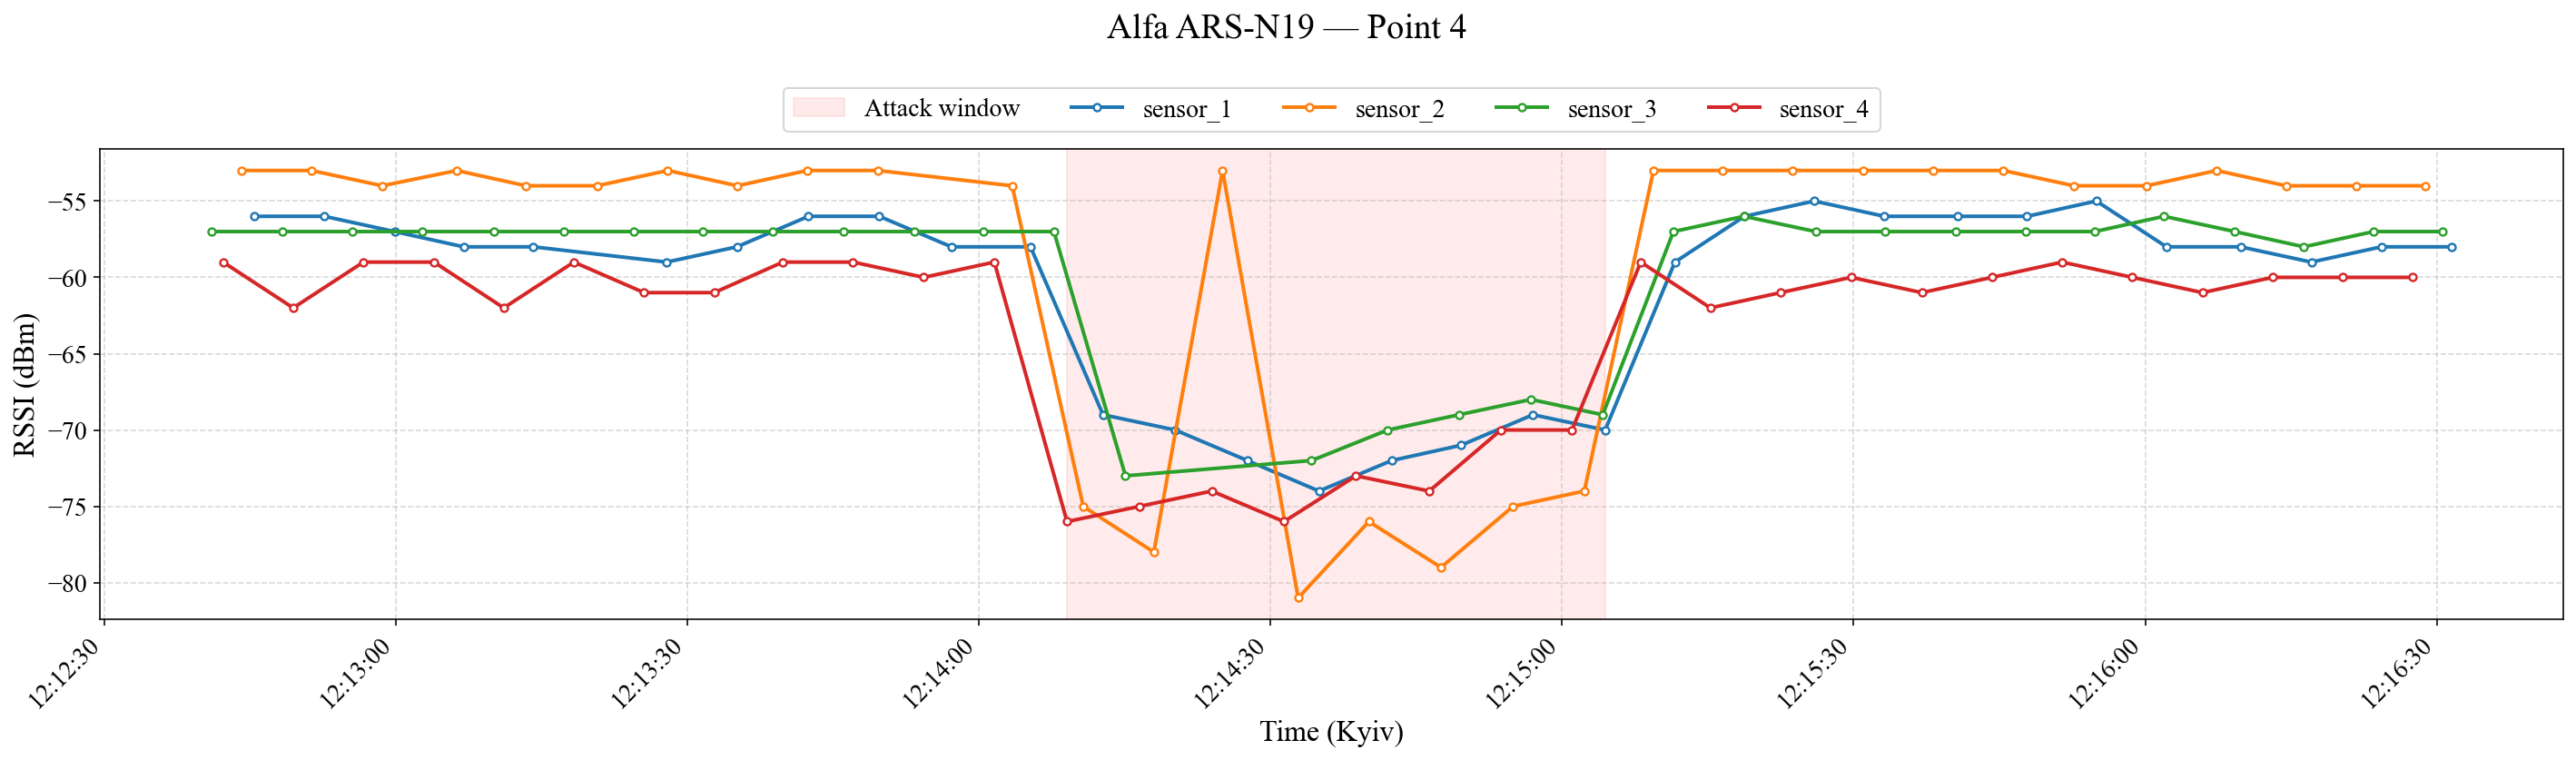

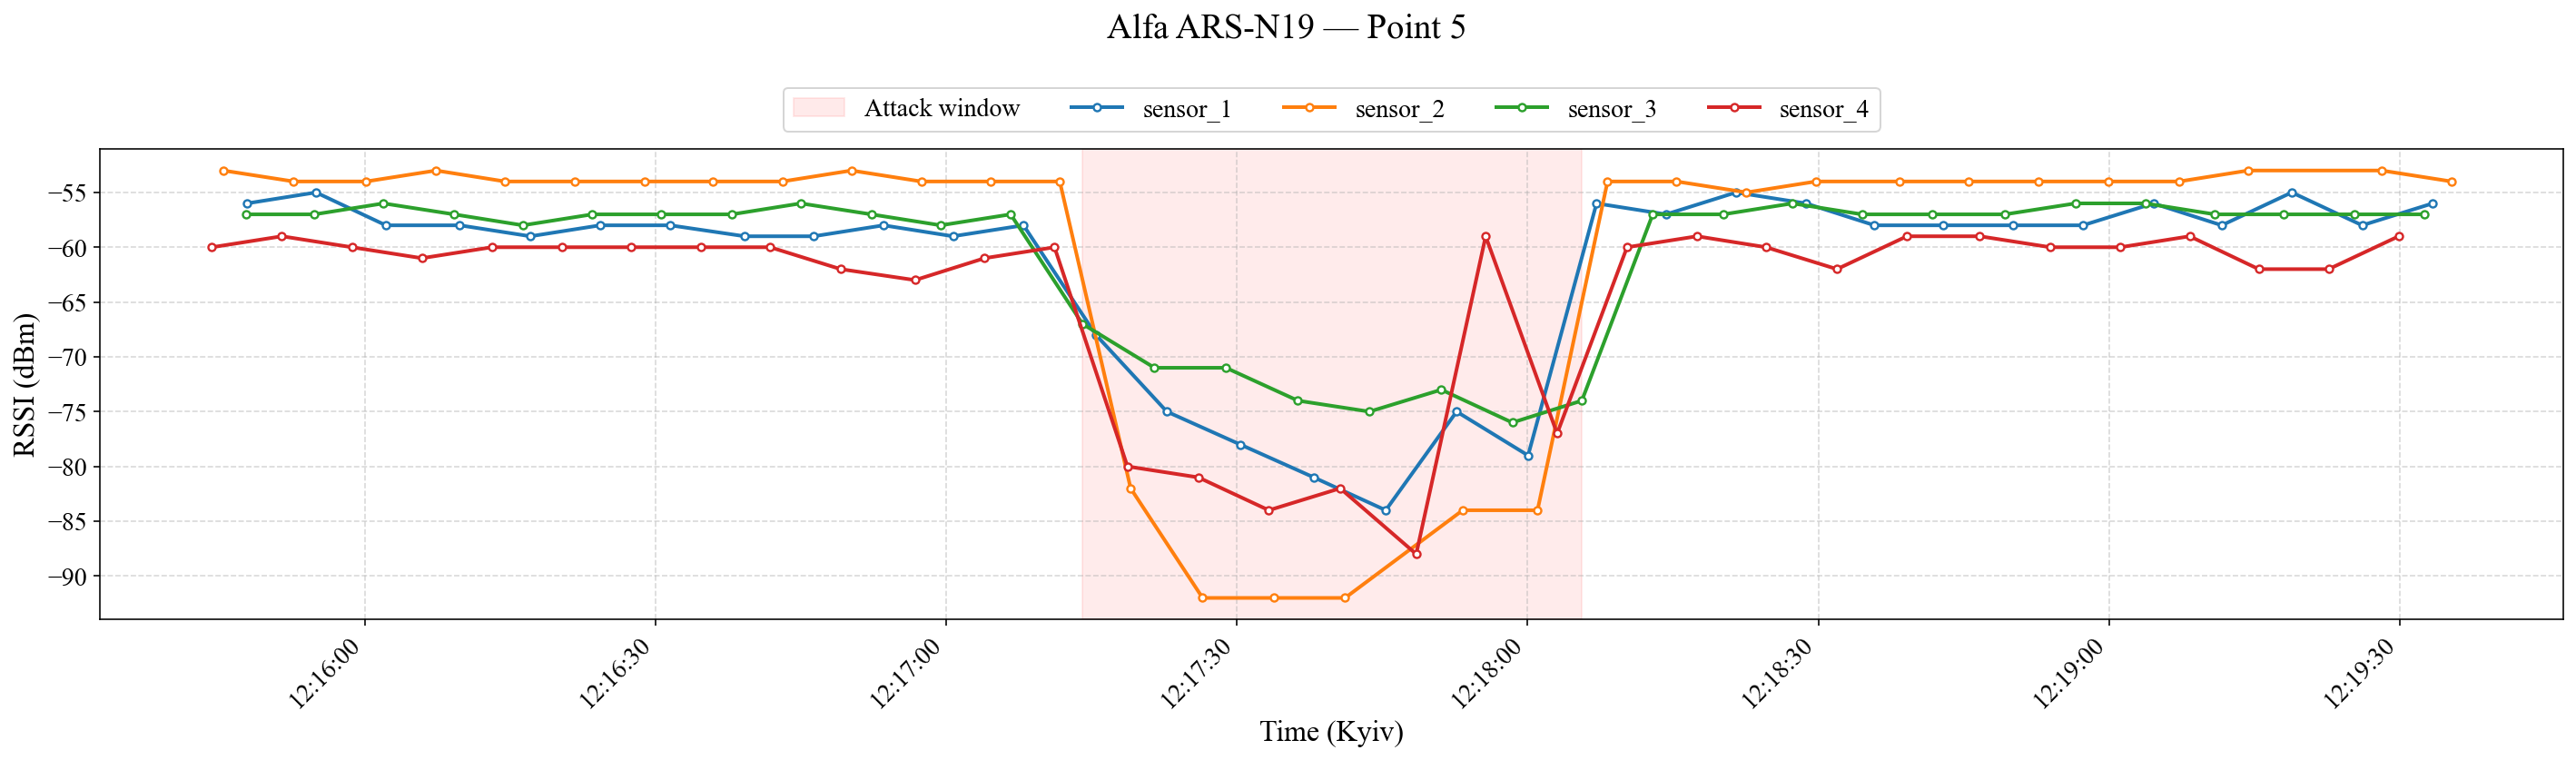

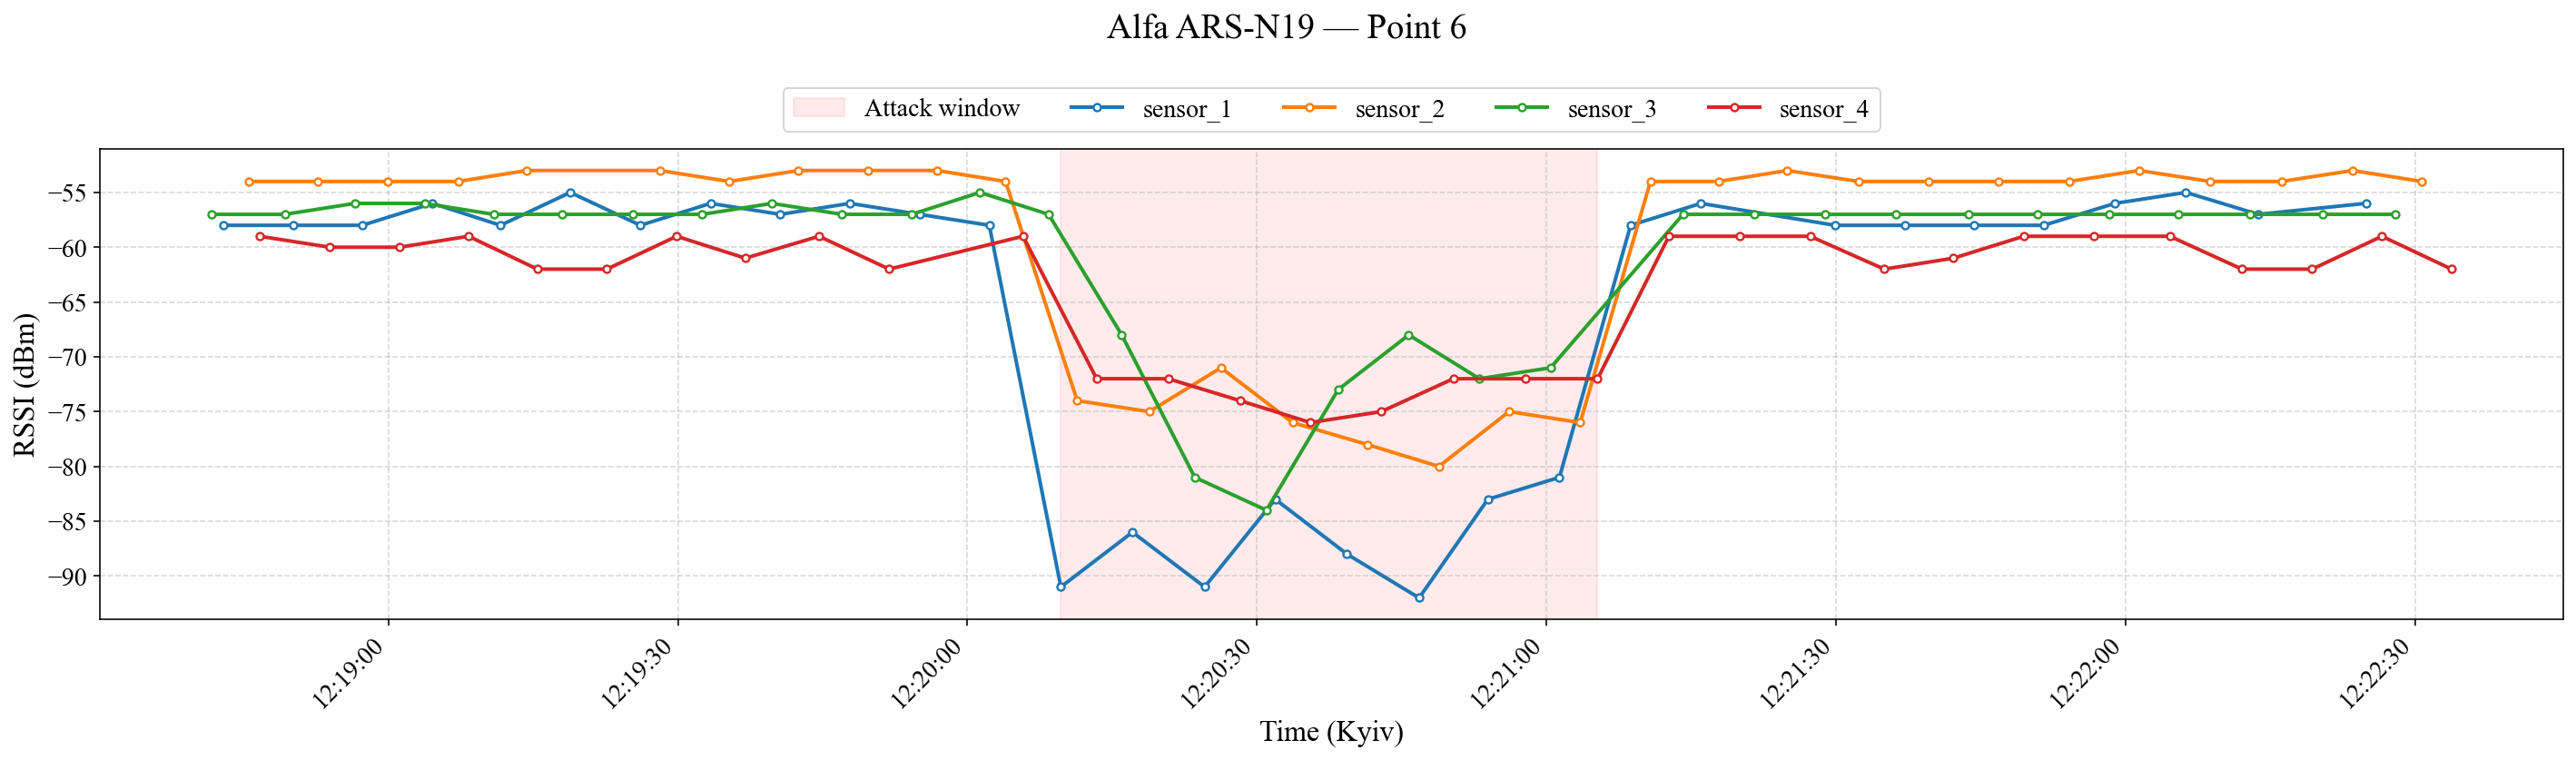

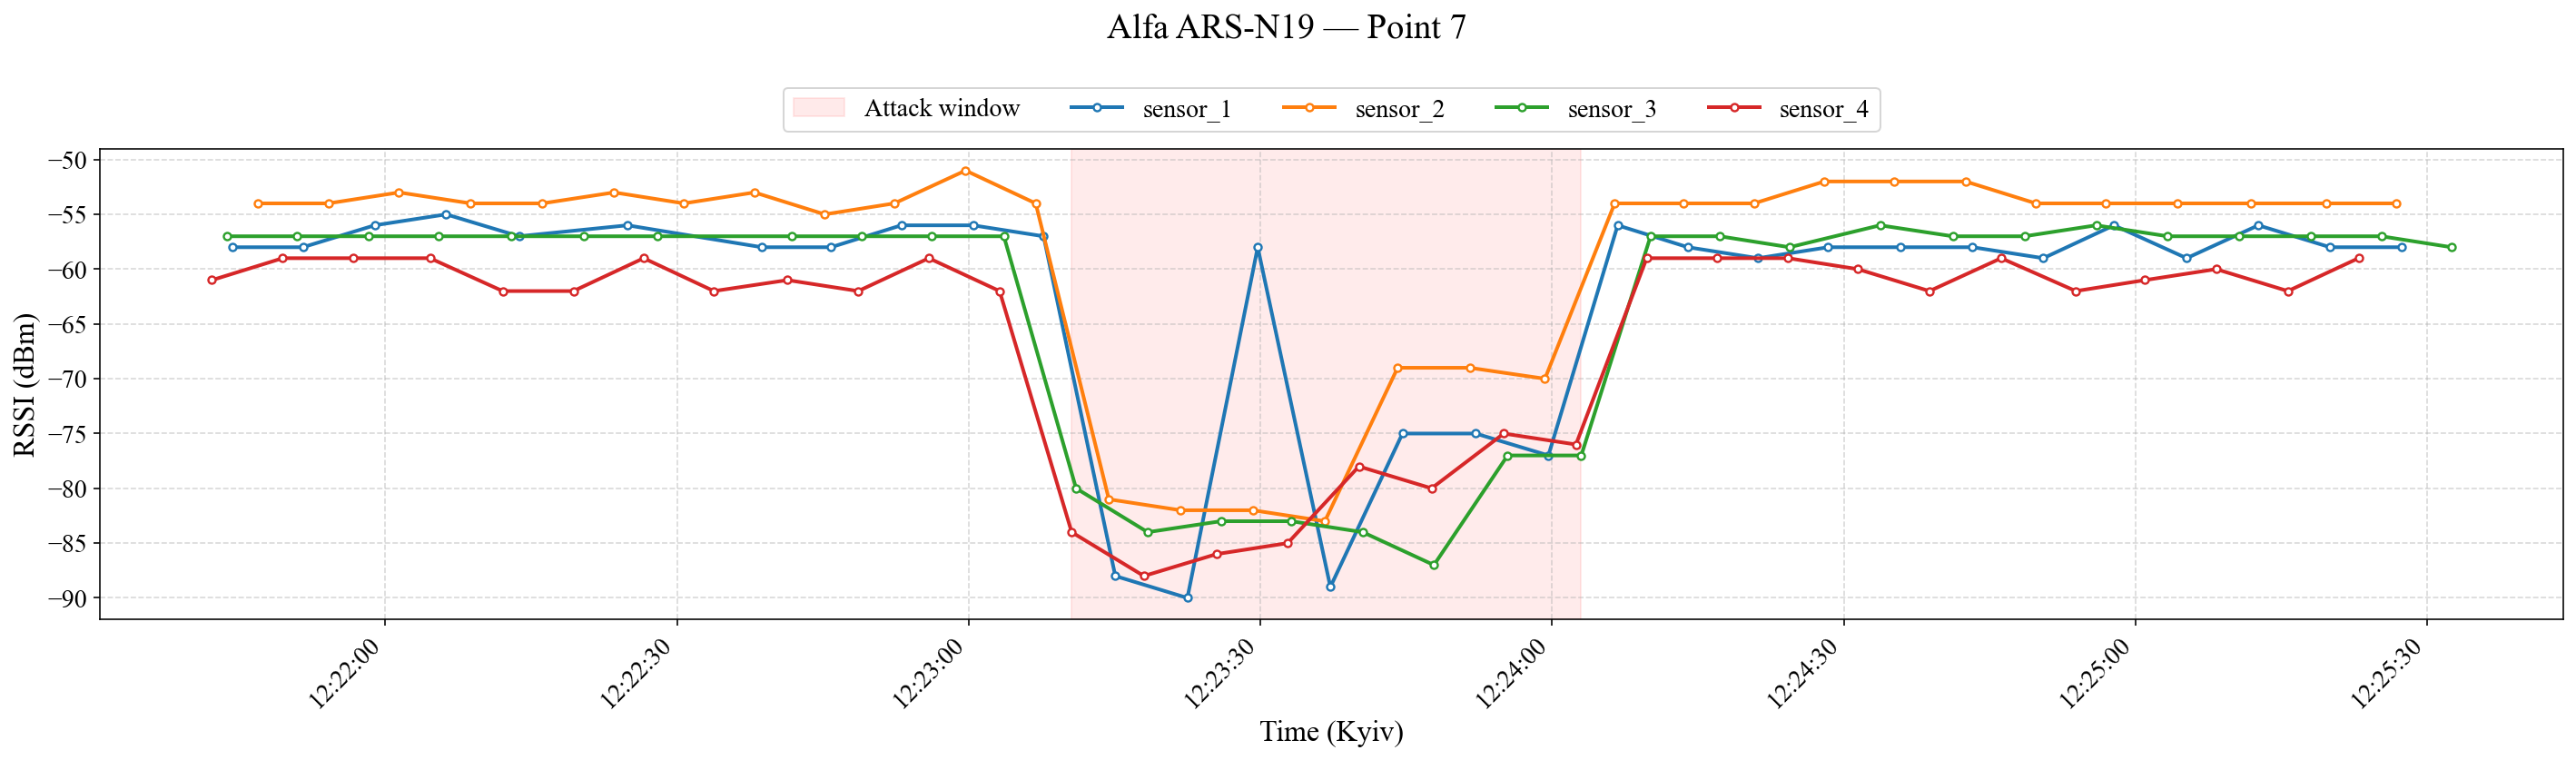

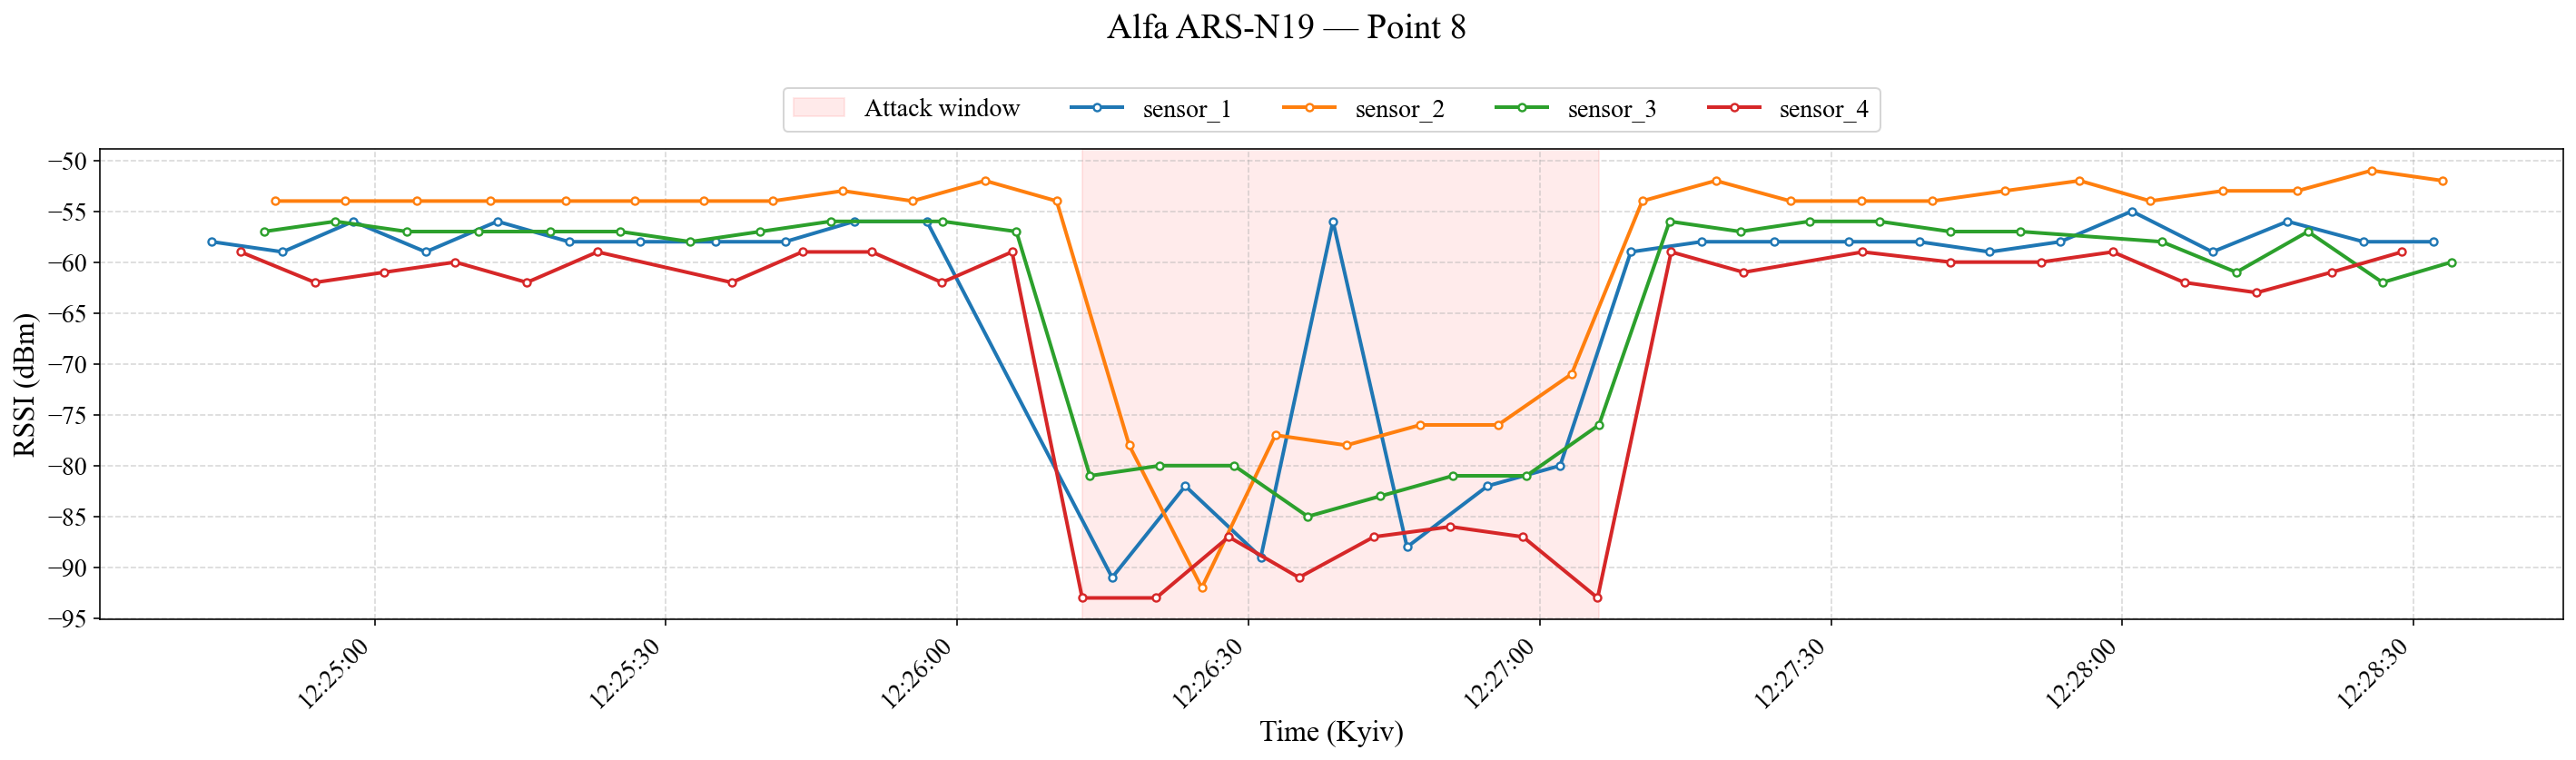

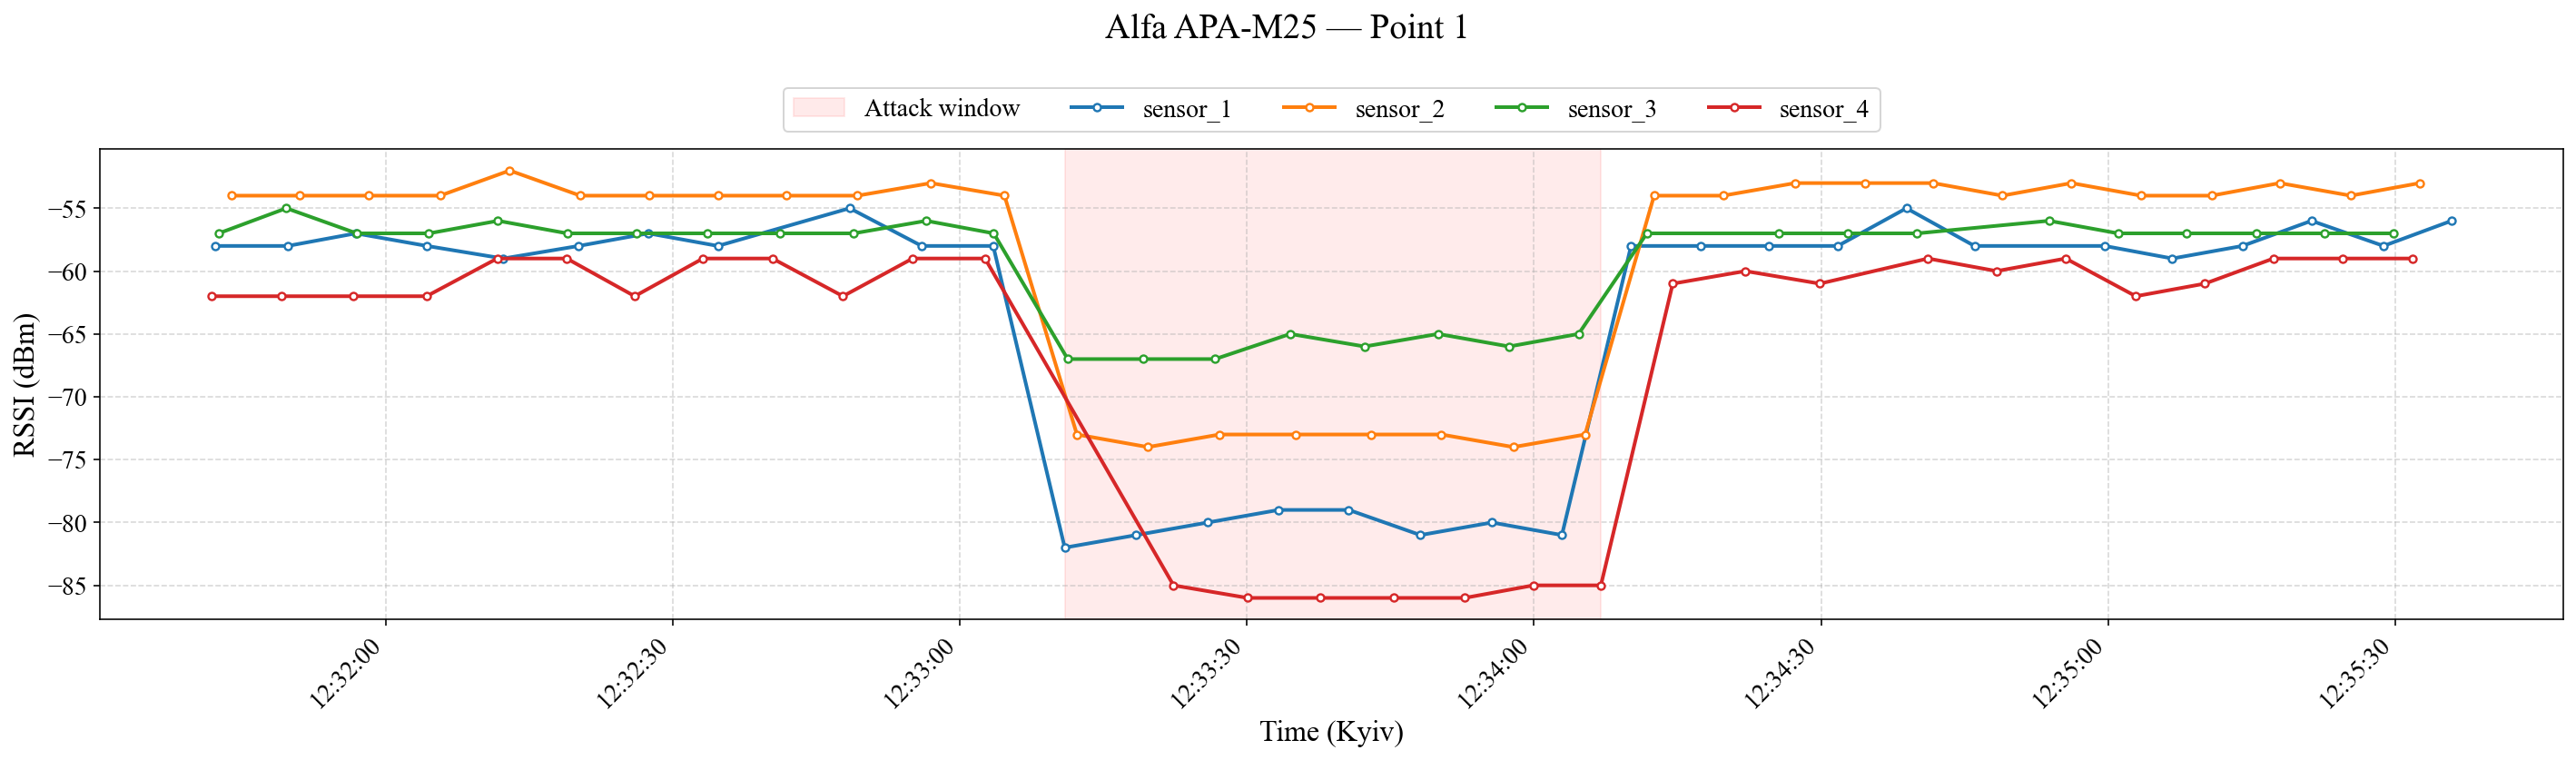

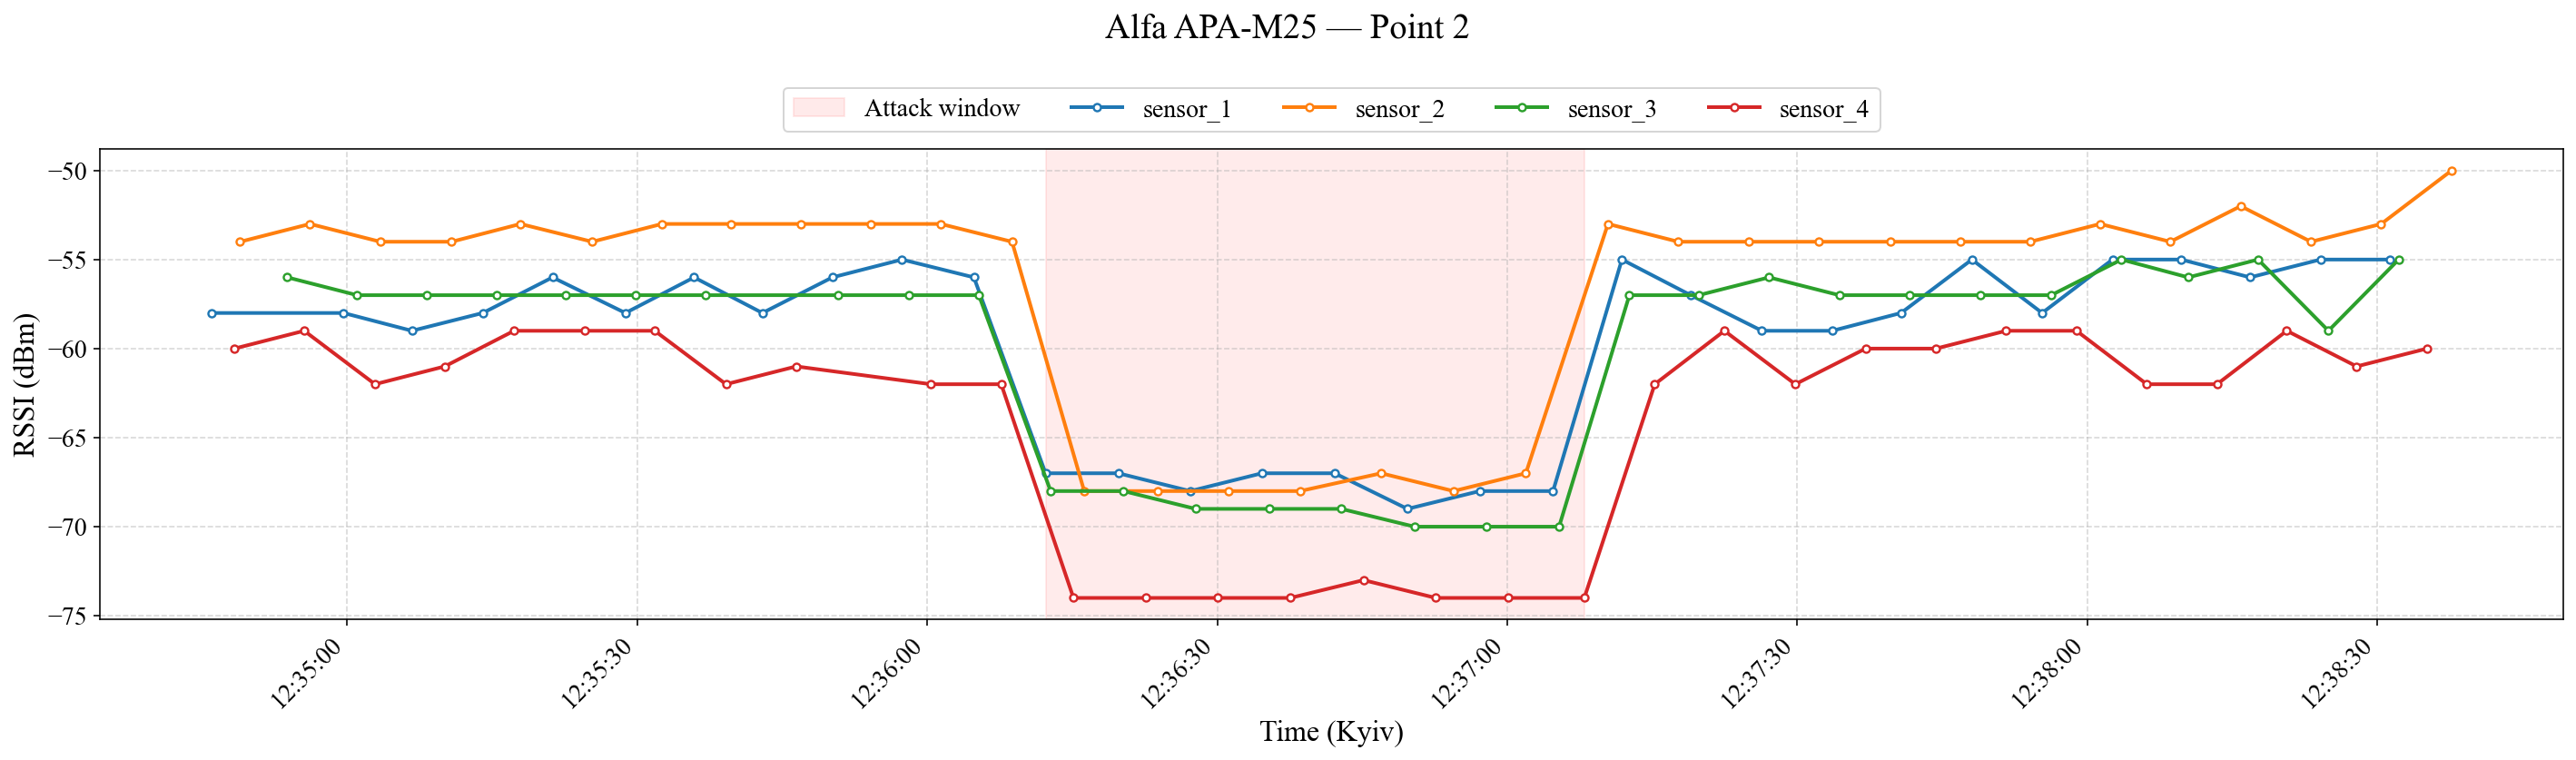

KeyboardInterrupt: 

In [ ]:
BUFFER_SECONDS = 90

# Attack windows per (antenna, point), derived straight from the labeled raw readings
windows = (
    raw[raw["attack"] == 1]
    .groupby(["antenna", "point"])["time"]
    .agg(start="min", end="max")
    .reset_index()
    .sort_values(["antenna", "point"])
)

for _, row in windows.iterrows():
    antenna_name = ANTENNA_NAMES[row["antenna"]]
    point        = row["point"]
    start_dt     = row["start"]
    end_dt       = row["end"]

    win_start = start_dt - pd.Timedelta(seconds=BUFFER_SECONDS)
    win_end   = end_dt   + pd.Timedelta(seconds=BUFFER_SECONDS)
    df_q      = raw[(raw["time"] >= win_start) & (raw["time"] <= win_end)]

    fig, ax = plt.subplots(figsize=(20, 6))
    ax.axvspan(start_dt, end_dt, alpha=0.08, color='red', label='Attack window')

    for device in sorted(df_q["deviceID"].unique()):
        dev_df = df_q[df_q["deviceID"] == device].sort_values("time")
        ax.plot(dev_df["time"], dev_df["value"], label=device, linewidth=2,
                marker='o', markersize=4, markerfacecolor='white', markeredgewidth=1.2)

    fig.suptitle(f"{antenna_name} — Point {point}", y=0.98)
    ax.yaxis.set_major_locator(plt.MultipleLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    ax.set_xlabel("Time (Kyiv)")
    ax.set_ylabel("RSSI (dBm)")
    ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=5)
    ax.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(rect=[0, 0, 1, 1.05])
    plt.show()

## 4. Build ML Dataset

The model needs a synchronized vector `[s1, s2, s3, s4]` for every timestamp, so here the raw, unsynchronized readings are resampled onto a common 5-second grid and merged (inner join) across all sensors.

In [ ]:
# Resample each sensor to a 5s grid, fill gaps with nearest value
sensors = {}
for i in range(1, 5):
    s = raw[raw["deviceID"] == f"sensor_{i}"][["time", "value"]].copy()
    s = s.set_index("time").sort_index()
    s = s.resample("5s").median()
    s = s.interpolate(method="nearest")
    s = s.rename(columns={"value": f"s{i}"})
    sensors[i] = s

# Inner join — keep only timestamps where all 4 sensors have data
df_pivot = sensors[1]
for i in range(2, 5):
    df_pivot = df_pivot.join(sensors[i], how="inner")

df_pivot = df_pivot.dropna().reset_index()

# Attach point/attack/antenna labels via nearest-time match against the raw labels
labels = raw[["time", "point", "attack", "antenna"]].drop_duplicates("time").sort_values("time")
dataset = pd.merge_asof(df_pivot.sort_values("time"), labels, on="time", direction="nearest")
dataset = dataset[["time", "s1", "s2", "s3", "s4", "point", "attack", "antenna"]]

print(f"Dataset shape: {dataset.shape}")
print(f"\nAttack distribution:\n{dataset['attack'].value_counts().to_string()}")
print(f"\nPoint distribution:\n{dataset['point'].value_counts().sort_index().to_string()}")
print(f"\nAntenna distribution:")
for code_val, count in dataset["antenna"].value_counts().sort_index().items():
    print(f"  {code_val} ({ANTENNA_NAMES[code_val]}): {count}")

dataset.head(20)

Dataset shape: (2131, 8)

Attack distribution:
0    1560
1     571

Point distribution:
0    1560
1      70
2      70
3      77
4      72
5      70
6      69
7      70
8      73

Antenna distribution:
  0 (none): 1560
  1 (Alfa ARS-N05): 93
  2 (Alfa ARS-N19): 91
  3 (Alfa APA-M25): 95
  4 (AOSIYANT Yagi 16dBi): 102
  5 (Logperiodic): 91
  6 (Alfa APA-M04): 99


,time,s1,s2,s3,s4,point,attack,antenna
0,2026-05-23 14:30:05+03:00,-56.0,-54.0,-62.0,-60.0,0,0,0
1,2026-05-23 14:30:10+03:00,-55.0,-54.0,-64.0,-60.0,0,0,0
2,2026-05-23 14:30:15+03:00,-56.0,-53.0,-55.0,-60.0,0,0,0
3,2026-05-23 14:30:20+03:00,-56.0,-54.0,-55.0,-59.0,0,0,0
4,2026-05-23 14:30:25+03:00,-55.0,-54.0,-57.0,-61.0,0,0,0
5,2026-05-23 14:30:30+03:00,-56.0,-53.0,-57.0,-61.0,0,0,0
6,2026-05-23 14:30:35+03:00,-56.0,-54.0,-57.0,-59.0,0,0,0
7,2026-05-23 14:30:40+03:00,-56.0,-54.0,-56.0,-61.0,0,0,0
8,2026-05-23 14:30:45+03:00,-55.0,-56.0,-56.0,-61.0,0,0,0
9,2026-05-23 14:30:50+03:00,-55.0,-54.0,-56.0,-57.0,0,0,0


## 5. ML Models

### Cascade approach

Three separate classifiers:
1. **Attack Detection** — binary (attack / no attack) — trained on full dataset
2. **Point Prediction** — multiclass (1–8) — trained on attack samples only
3. **Antenna Prediction** — multiclass (1–6) — trained on attack samples only

In [ ]:
features = ["s1", "s2", "s3", "s4"]
X = dataset[features]

# ── Split: full dataset (for attack detection) ──
y_attack = dataset["attack"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_attack, test_size=0.25, random_state=42, stratify=y_attack
)

# ── Split: attack-only (for point & antenna) ──
attack_mask = dataset["attack"] == 1
X_attack    = dataset.loc[attack_mask, features]
y_point     = dataset.loc[attack_mask, "point"]
y_antenna   = dataset.loc[attack_mask, "antenna"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_attack, y_point, test_size=0.25, random_state=42, stratify=y_point
)
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_attack, y_antenna, test_size=0.25, random_state=42, stratify=y_antenna
)

print(f"Full dataset:   train={len(X_train)}, test={len(X_test)}")
print(f"Attack-only:    train={len(X_train_p)}, test={len(X_test_p)}")

Full dataset:   train=1598, test=533
Attack-only:    train=428, test=143


### 5.1 Random Forest

In [ ]:
# Model 1: Attack Detection
rf_attack = RandomForestClassifier(n_estimators=200, random_state=42)
rf_attack.fit(X_train, y_train)
y_pred_attack = rf_attack.predict(X_test)

print("=" * 55)
print("MODEL 1: Attack Detection (Random Forest)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred_attack):.3f}")
print(f"Cross-val (5-fold): {cross_val_score(rf_attack, X, y_attack, cv=5).mean():.3f}")
print(f"\n{classification_report(y_test, y_pred_attack, target_names=['No Attack', 'Attack'])}")

# Model 2: Point Prediction
rf_point = RandomForestClassifier(n_estimators=200, random_state=42)
rf_point.fit(X_train_p, y_train_p)
y_pred_point = rf_point.predict(X_test_p)

print("=" * 55)
print("MODEL 2: Point Prediction (Random Forest)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test_p, y_pred_point):.3f}")
print(f"Cross-val (5-fold): {cross_val_score(rf_point, X_attack, y_point, cv=5).mean():.3f}")
print(f"\n{classification_report(y_test_p, y_pred_point, zero_division=0)}")

# Model 3: Antenna Prediction
rf_antenna = RandomForestClassifier(n_estimators=200, random_state=42)
rf_antenna.fit(X_train_a, y_train_a)
y_pred_antenna = rf_antenna.predict(X_test_a)

print("=" * 55)
print("MODEL 3: Antenna Prediction (Random Forest)")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test_a, y_pred_antenna):.3f}")
print(f"Cross-val (5-fold): {cross_val_score(rf_antenna, X_attack, y_antenna, cv=5).mean():.3f}")
print(f"\n{classification_report(y_test_a, y_pred_antenna, zero_division=0)}")

MODEL 1: Attack Detection (Random Forest)
Accuracy: 0.985
Cross-val (5-fold): 0.987

              precision    recall  f1-score   support

   No Attack       0.99      0.98      0.99       390
      Attack       0.96      0.99      0.97       143

    accuracy                           0.98       533
   macro avg       0.98      0.99      0.98       533
weighted avg       0.99      0.98      0.99       533

MODEL 2: Point Prediction (Random Forest)
Accuracy: 0.846
Cross-val (5-fold): 0.809

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       0.93      0.82      0.87        17
           3       0.74      0.89      0.81        19
           4       0.74      0.78      0.76        18
           5       0.88      0.78      0.82        18
           6       0.92      0.71      0.80        17
           7       0.73      0.89      0.80        18
           8       0.94      0.89      0.91        18

    accuracy   

### 5.2 XGBoost

In [ ]:
# Model 1: Attack Detection
xgb_attack = XGBClassifier(n_estimators=200, max_depth=5, random_state=42, eval_metric="logloss")
xgb_attack.fit(X_train, y_train)
y_pred_attack_xgb = xgb_attack.predict(X_test)

# Model 2: Point Prediction (shift labels to 0-based for XGBoost)
xgb_point = XGBClassifier(n_estimators=200, max_depth=5, random_state=42, eval_metric="mlogloss")
xgb_point.fit(X_train_p, y_train_p - 1)
y_pred_point_xgb = xgb_point.predict(X_test_p) + 1

# Model 3: Antenna Prediction (shift labels to 0-based for XGBoost)
xgb_antenna = XGBClassifier(n_estimators=200, max_depth=3, random_state=42, eval_metric="mlogloss")
xgb_antenna.fit(X_train_a, y_train_a - 1)
y_pred_antenna_xgb = xgb_antenna.predict(X_test_a) + 1

# ── Summary table ──
rf_cv1  = cross_val_score(rf_attack,  X, y_attack, cv=5).mean()
xgb_cv1 = cross_val_score(xgb_attack, X, y_attack, cv=5).mean()
rf_cv2  = cross_val_score(rf_point,   X_attack, y_point, cv=5).mean()
xgb_cv2 = cross_val_score(xgb_point,  X_attack, y_point - 1, cv=5).mean()
rf_cv3  = cross_val_score(rf_antenna, X_attack, y_antenna, cv=5).mean()
xgb_cv3 = cross_val_score(xgb_antenna, X_attack, y_antenna - 1, cv=5).mean()

print("=" * 60)
print("RF vs XGBoost — Cross-Validation Comparison")
print("=" * 60)
print(f"{'Model':<25} {'RF CV':>8} {'XGB CV':>8} {'Winner':>10}")
print("-" * 60)
print(f"{'Attack Detection':<25} {rf_cv1:>8.3f} {xgb_cv1:>8.3f} {'RF' if rf_cv1 > xgb_cv1 else 'XGB':>10}")
print(f"{'Point Prediction':<25} {rf_cv2:>8.3f} {xgb_cv2:>8.3f} {'RF' if rf_cv2 > xgb_cv2 else 'XGB':>10}")
print(f"{'Antenna Prediction':<25} {rf_cv3:>8.3f} {xgb_cv3:>8.3f} {'RF' if rf_cv3 > xgb_cv3 else 'XGB':>10}")

KeyboardInterrupt: 

### 5.2b Extra Trees

`ExtraTreesClassifier` is the same type of tree ensemble as RF, but the split thresholds are chosen completely at random (rather than optimally), which gives higher variance across trees and often better generalization on small datasets.

In [ ]:
# Model 1: Attack Detection
et_attack = ExtraTreesClassifier(n_estimators=200, random_state=42)
et_attack.fit(X_train, y_train)
y_pred_attack_et = et_attack.predict(X_test)

# Model 2: Point Prediction
et_point = ExtraTreesClassifier(n_estimators=200, random_state=42)
et_point.fit(X_train_p, y_train_p)
y_pred_point_et = et_point.predict(X_test_p)

# Model 3: Antenna Prediction
et_antenna = ExtraTreesClassifier(n_estimators=200, random_state=42)
et_antenna.fit(X_train_a, y_train_a)
y_pred_antenna_et = et_antenna.predict(X_test_a)

# ── Extend summary table ──
et_cv1 = cross_val_score(et_attack,  X, y_attack, cv=5).mean()
et_cv2 = cross_val_score(et_point,   X_attack, y_point, cv=5).mean()
et_cv3 = cross_val_score(et_antenna, X_attack, y_antenna, cv=5).mean()

print("=" * 70)
print("RF vs XGBoost vs Extra Trees — Cross-Validation Comparison")
print("=" * 70)
print(f"{'Model':<25} {'RF CV':>8} {'XGB CV':>8} {'ET CV':>8} {'Winner':>10}")
print("-" * 70)
for name, rf_cv, xgb_cv, et_cv in [
    ("Attack Detection",  rf_cv1, xgb_cv1, et_cv1),
    ("Point Prediction",  rf_cv2, xgb_cv2, et_cv2),
    ("Antenna Prediction", rf_cv3, xgb_cv3, et_cv3),
]:
    best = max([("RF", rf_cv), ("XGB", xgb_cv), ("ET", et_cv)], key=lambda t: t[1])[0]
    print(f"{name:<25} {rf_cv:>8.3f} {xgb_cv:>8.3f} {et_cv:>8.3f} {best:>10}")

RF vs XGBoost vs Extra Trees — Cross-Validation Comparison
Model                        RF CV   XGB CV    ET CV     Winner
----------------------------------------------------------------------
Attack Detection             0.987    0.986    0.987         ET
Point Prediction             0.809    0.766    0.809         ET
Antenna Prediction           0.441    0.403    0.457         ET


### 5.2c LightGBM & CatBoost

Two more gradient boosting methods alongside XGBoost — both have native support for arbitrary (not 0-based) class labels, so no label shifting is needed.

In [ ]:
def make_lgbm(**kw):
    return LGBMClassifier(n_estimators=200, random_state=42, verbosity=-1, **kw)

def make_cat(**kw):
    return CatBoostClassifier(n_estimators=200, random_state=42, verbose=False, **kw)

# Model 1: Attack Detection
lgbm_attack = make_lgbm(max_depth=5); lgbm_attack.fit(X_train, y_train)
cat_attack  = make_cat(max_depth=5);  cat_attack.fit(X_train, y_train)

# Model 2: Point Prediction
lgbm_point = make_lgbm(max_depth=5); lgbm_point.fit(X_train_p, y_train_p)
cat_point  = make_cat(max_depth=5);  cat_point.fit(X_train_p, y_train_p)

# Model 3: Antenna Prediction
lgbm_antenna = make_lgbm(max_depth=3); lgbm_antenna.fit(X_train_a, y_train_a)
cat_antenna  = make_cat(max_depth=3);  cat_antenna.fit(X_train_a, y_train_a)

# ── Extend summary table ──
lgbm_cv1 = cross_val_score(make_lgbm(max_depth=5), X, y_attack, cv=5).mean()
lgbm_cv2 = cross_val_score(make_lgbm(max_depth=5), X_attack, y_point, cv=5).mean()
lgbm_cv3 = cross_val_score(make_lgbm(max_depth=3), X_attack, y_antenna, cv=5).mean()

cat_cv1 = cross_val_score(make_cat(max_depth=5), X, y_attack, cv=5).mean()
cat_cv2 = cross_val_score(make_cat(max_depth=5), X_attack, y_point, cv=5).mean()
cat_cv3 = cross_val_score(make_cat(max_depth=3), X_attack, y_antenna, cv=5).mean()

print("=" * 80)
print("RF vs XGBoost vs Extra Trees vs LightGBM vs CatBoost — Cross-Validation Comparison")
print("=" * 80)
print(f"{'Model':<22} {'RF':>7} {'XGB':>7} {'ET':>7} {'LGBM':>7} {'CatB':>7} {'Winner':>10}")
print("-" * 80)
for name, rf_cv, xgb_cv, et_cv, lgbm_cv, cat_cv in [
    ("Attack Detection",   rf_cv1, xgb_cv1, et_cv1, lgbm_cv1, cat_cv1),
    ("Point Prediction",   rf_cv2, xgb_cv2, et_cv2, lgbm_cv2, cat_cv2),
    ("Antenna Prediction", rf_cv3, xgb_cv3, et_cv3, lgbm_cv3, cat_cv3),
]:
    scores = [("RF", rf_cv), ("XGB", xgb_cv), ("ET", et_cv), ("LGBM", lgbm_cv), ("CatB", cat_cv)]
    best = max(scores, key=lambda t: t[1])[0]
    print(f"{name:<22} {rf_cv:>7.3f} {xgb_cv:>7.3f} {et_cv:>7.3f} {lgbm_cv:>7.3f} {cat_cv:>7.3f} {best:>10}")

RF vs XGBoost vs Extra Trees vs LightGBM vs CatBoost — Cross-Validation Comparison
Model                       RF     XGB      ET    LGBM    CatB     Winner
--------------------------------------------------------------------------------
Attack Detection         0.987   0.986   0.987   0.985   0.987         ET
Point Prediction         0.809   0.766   0.809   0.774   0.799         ET
Antenna Prediction       0.441   0.403   0.457   0.382   0.429         ET


### 5.3 Classical Baselines

Logistic Regression, SVM, k-NN, and Decision Tree — to show how much the ensemble methods (RF, XGBoost) outperform simpler classifiers on this task.

In [ ]:
# Logistic Regression / SVM / KNN are distance- or gradient-based, so features are scaled;
# Decision Tree is scale-invariant and left as-is.
baseline_models = {
    "Logistic Regression": lambda: make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42)),
    "SVM (RBF)":            lambda: make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42)),
    "KNN (k=5)":            lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Decision Tree":        lambda: DecisionTreeClassifier(max_depth=8, random_state=42),
}

baseline_cv = {}

for name, make_model in baseline_models.items():
    m1 = make_model(); m1.fit(X_train, y_train)
    acc1 = accuracy_score(y_test, m1.predict(X_test))
    cv1  = cross_val_score(make_model(), X, y_attack, cv=5).mean()

    m2 = make_model(); m2.fit(X_train_p, y_train_p)
    acc2 = accuracy_score(y_test_p, m2.predict(X_test_p))
    cv2  = cross_val_score(make_model(), X_attack, y_point, cv=5).mean()

    m3 = make_model(); m3.fit(X_train_a, y_train_a)
    acc3 = accuracy_score(y_test_a, m3.predict(X_test_a))
    cv3  = cross_val_score(make_model(), X_attack, y_antenna, cv=5).mean()

    baseline_cv[name] = (cv1, cv2, cv3)

    print("=" * 55)
    print(f"{name}")
    print("=" * 55)
    print(f"Attack Detection:    acc={acc1:.3f}  cv={cv1:.3f}")
    print(f"Point Prediction:    acc={acc2:.3f}  cv={cv2:.3f}")
    print(f"Antenna Prediction:  acc={acc3:.3f}  cv={cv3:.3f}\n")

Logistic Regression
Attack Detection:    acc=0.992  cv=0.986
Point Prediction:    acc=0.769  cv=0.722
Antenna Prediction:  acc=0.378  cv=0.363

SVM (RBF)
Attack Detection:    acc=0.985  cv=0.988
Point Prediction:    acc=0.783  cv=0.766
Antenna Prediction:  acc=0.531  cv=0.371

KNN (k=5)
Attack Detection:    acc=0.987  cv=0.987
Point Prediction:    acc=0.797  cv=0.762
Antenna Prediction:  acc=0.804  cv=0.466

Decision Tree
Attack Detection:    acc=0.983  cv=0.980
Point Prediction:    acc=0.811  cv=0.724
Antenna Prediction:  acc=0.650  cv=0.340



### 5.3b Probabilistic Models (Naive Bayes, LDA, QDA)

Gaussian Naive Bayes, LDA, and QDA model each class as a (conditionally) Gaussian distribution in the `[s1, s2, s3, s4]` space. Cheap, with no hyperparameters — interesting to check whether the shape of the per-class RSSI clouds is Gaussian enough to compete with tree-based models.

In [ ]:
# Scale-invariant (affine transforms don't change LDA/QDA/GaussianNB boundaries) — no scaler needed.
prob_models = {
    "Gaussian NB": lambda: GaussianNB(),
    "LDA":         lambda: LinearDiscriminantAnalysis(),
    "QDA":         lambda: QuadraticDiscriminantAnalysis(),
}

for name, make_model in prob_models.items():
    m1 = make_model(); m1.fit(X_train, y_train)
    acc1 = accuracy_score(y_test, m1.predict(X_test))
    cv1  = cross_val_score(make_model(), X, y_attack, cv=5).mean()

    m2 = make_model(); m2.fit(X_train_p, y_train_p)
    acc2 = accuracy_score(y_test_p, m2.predict(X_test_p))
    cv2  = cross_val_score(make_model(), X_attack, y_point, cv=5).mean()

    m3 = make_model(); m3.fit(X_train_a, y_train_a)
    acc3 = accuracy_score(y_test_a, m3.predict(X_test_a))
    cv3  = cross_val_score(make_model(), X_attack, y_antenna, cv=5).mean()

    baseline_cv[name] = (cv1, cv2, cv3)

    print("=" * 55)
    print(f"{name}")
    print("=" * 55)
    print(f"Attack Detection:    acc={acc1:.3f}  cv={cv1:.3f}")
    print(f"Point Prediction:    acc={acc2:.3f}  cv={cv2:.3f}")
    print(f"Antenna Prediction:  acc={acc3:.3f}  cv={cv3:.3f}\n")

Gaussian NB
Attack Detection:    acc=0.987  cv=0.984
Point Prediction:    acc=0.685  cv=0.652
Antenna Prediction:  acc=0.350  cv=0.328

LDA
Attack Detection:    acc=0.989  cv=0.985
Point Prediction:    acc=0.783  cv=0.745
Antenna Prediction:  acc=0.371  cv=0.357

QDA
Attack Detection:    acc=0.987  cv=0.979
Point Prediction:    acc=0.741  cv=0.737
Antenna Prediction:  acc=0.406  cv=0.310



### 5.4 Full Model Comparison

In [ ]:
all_cv = dict(baseline_cv)
all_cv["Random Forest"] = (rf_cv1, rf_cv2, rf_cv3)
all_cv["XGBoost"]       = (xgb_cv1, xgb_cv2, xgb_cv3)
all_cv["Extra Trees"]   = (et_cv1, et_cv2, et_cv3)
all_cv["LightGBM"]      = (lgbm_cv1, lgbm_cv2, lgbm_cv3)
all_cv["CatBoost"]      = (cat_cv1, cat_cv2, cat_cv3)

print("=" * 70)
print("Model Comparison — 5-fold Cross-Validation Accuracy")
print("=" * 70)
print(f"{'Model':<22} {'Attack Det.':>12} {'Point Pred.':>12} {'Antenna Pred.':>14}")
print("-" * 70)
for name, (cv1, cv2, cv3) in all_cv.items():
    print(f"{name:<22} {cv1:>12.3f} {cv2:>12.3f} {cv3:>14.3f}")

Model Comparison — 5-fold Cross-Validation Accuracy
Model                   Attack Det.  Point Pred.  Antenna Pred.
----------------------------------------------------------------------
Logistic Regression           0.986        0.722          0.363
SVM (RBF)                     0.988        0.766          0.371
KNN (k=5)                     0.987        0.762          0.466
Decision Tree                 0.980        0.724          0.340
Gaussian NB                   0.984        0.652          0.328
LDA                           0.985        0.745          0.357
QDA                           0.979        0.737          0.310
Random Forest                 0.987        0.809          0.441
XGBoost                       0.986        0.766          0.403
Extra Trees                   0.987        0.809          0.457
LightGBM                      0.985        0.774          0.382
CatBoost                      0.987        0.799          0.429


### 5.5 Anomaly Detection Framing (Attack Detection only)

Instead of binary classification, we train `IsolationForest` and `OneClassSVM` **only on "no attack" samples** — they learn the shape of the normal signal, and an attack is detected as a deviation from it. This is a different problem framing: no attack labels are used during training, so it is interesting to see how much it loses/gains compared to the supervised models in 5.1-5.2c.

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

X_train_normal = X_train[y_train == 0]
contamination = float(y_attack.mean())  # actual attack rate — used as the unsupervised decision threshold

# Isolation Forest
iso = IsolationForest(n_estimators=200, contamination=contamination, random_state=42)
iso.fit(X_train_normal)
y_pred_iso = pd.Series((iso.predict(X_test) == -1).astype(int), index=X_test.index)

# One-Class SVM (distance-based, needs scaling; scaler fit on normal training data only)
scaler_ocsvm = StandardScaler().fit(X_train_normal)
ocsvm = OneClassSVM(kernel="rbf", nu=contamination, gamma="scale")
ocsvm.fit(scaler_ocsvm.transform(X_train_normal))
y_pred_ocsvm = pd.Series((ocsvm.predict(scaler_ocsvm.transform(X_test)) == -1).astype(int), index=X_test.index)

iso_cv1   = accuracy_score(y_test, y_pred_iso)
ocsvm_cv1 = accuracy_score(y_test, y_pred_ocsvm)

print("=" * 55)
print("Isolation Forest (trained on normal-only data)")
print("=" * 55)
print(f"Accuracy: {iso_cv1:.3f}")
print(f"\n{classification_report(y_test, y_pred_iso, target_names=['No Attack', 'Attack'], zero_division=0)}")

print("=" * 55)
print("One-Class SVM (trained on normal-only data)")
print("=" * 55)
print(f"Accuracy: {ocsvm_cv1:.3f}")
print(f"\n{classification_report(y_test, y_pred_ocsvm, target_names=['No Attack', 'Attack'], zero_division=0)}")

print("=" * 55)
print(f"Supervised Extra Trees (5.2b), for reference: acc={accuracy_score(y_test, y_pred_attack_et):.3f}, cv={et_cv1:.3f}")

/Users/stealth/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Isolation Forest (trained on normal-only data)
Accuracy: 0.792

              precision    recall  f1-score   support

   No Attack       1.00      0.72      0.83       390
      Attack       0.56      0.99      0.72       143

    accuracy                           0.79       533
   macro avg       0.78      0.86      0.78       533
weighted avg       0.88      0.79      0.80       533

One-Class SVM (trained on normal-only data)
Accuracy: 0.795

              precision    recall  f1-score   support

   No Attack       1.00      0.72      0.84       390
      Attack       0.57      1.00      0.72       143

    accuracy                           0.80       533
   macro avg       0.78      0.86      0.78       533
weighted avg       0.88      0.80      0.81       533

Supervised Extra Trees (5.2b), for reference: acc=0.987, cv=0.987


## 6. Evaluation Plots

### 6.1 Confusion Matrices

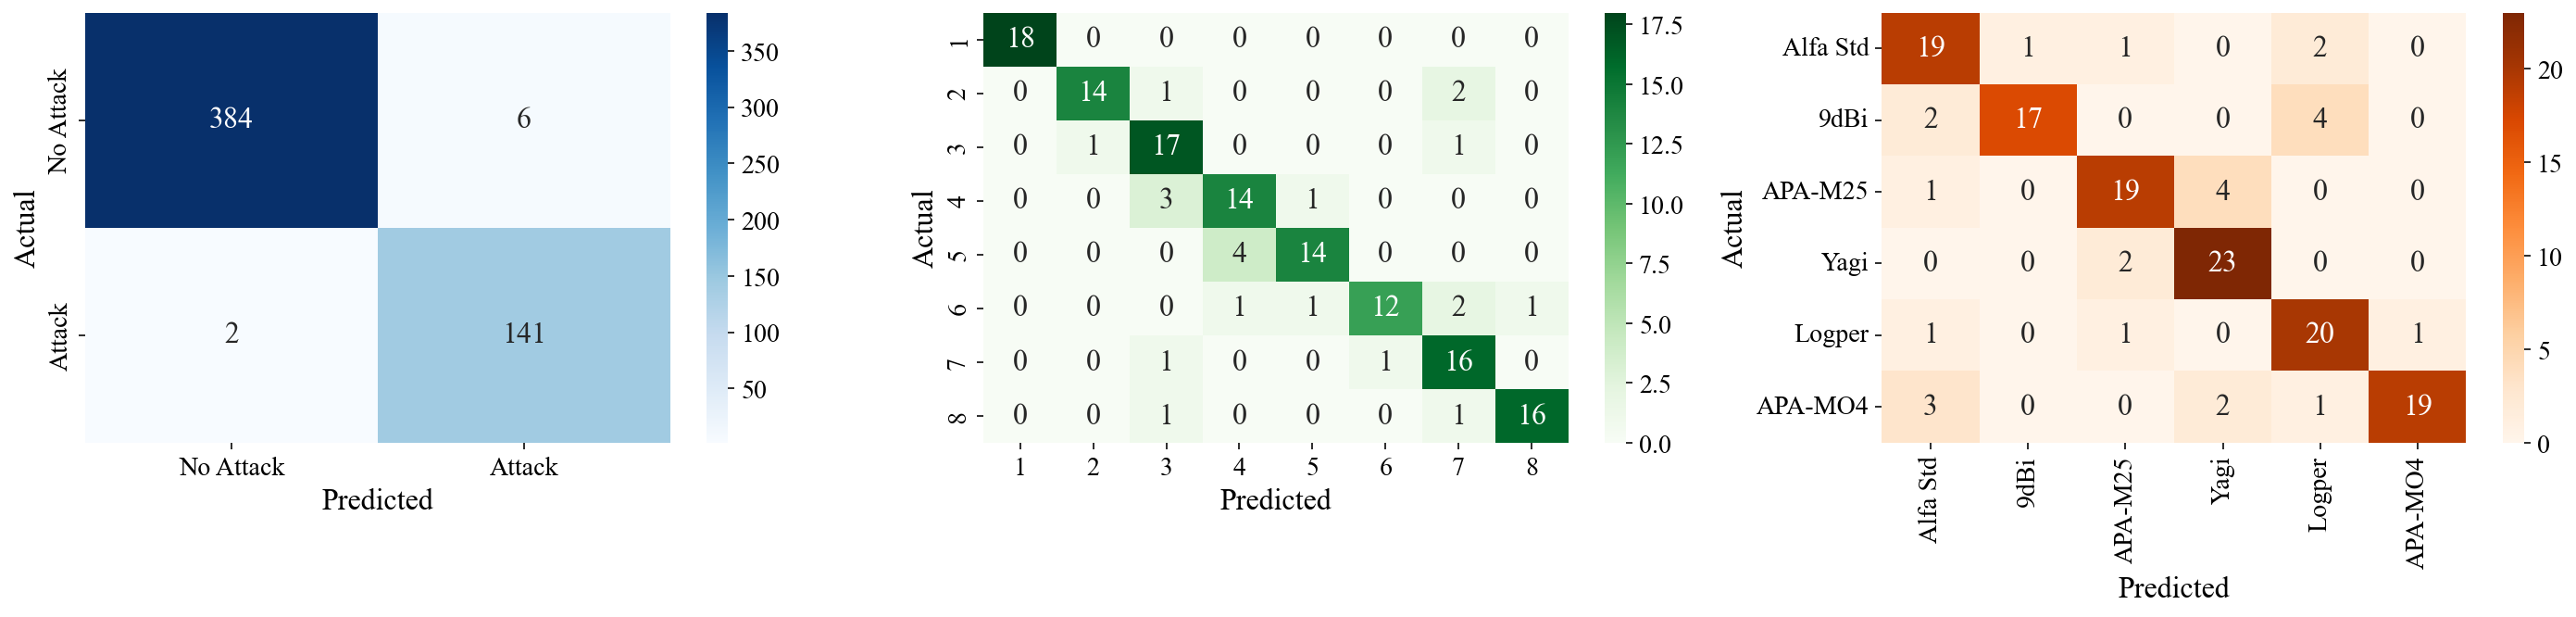

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Model 1
cm1 = confusion_matrix(y_test, y_pred_attack)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No Attack", "Attack"], yticklabels=["No Attack", "Attack"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Model 2
labels_p = sorted(y_point.unique())
cm2 = confusion_matrix(y_test_p, y_pred_point, labels=labels_p)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=labels_p, yticklabels=labels_p)
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

# Model 3
labels_a = sorted(y_antenna.unique())
antenna_short = ["ARS-N05", "ARS-N19", "APA-M25", "Yagi", "Logper", "APA-M04"]
cm3 = confusion_matrix(y_test_a, y_pred_antenna, labels=labels_a)
sns.heatmap(cm3, annot=True, fmt="d", cmap="Oranges", ax=axes[2],
            xticklabels=antenna_short, yticklabels=antenna_short)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 6.2 Feature Importance

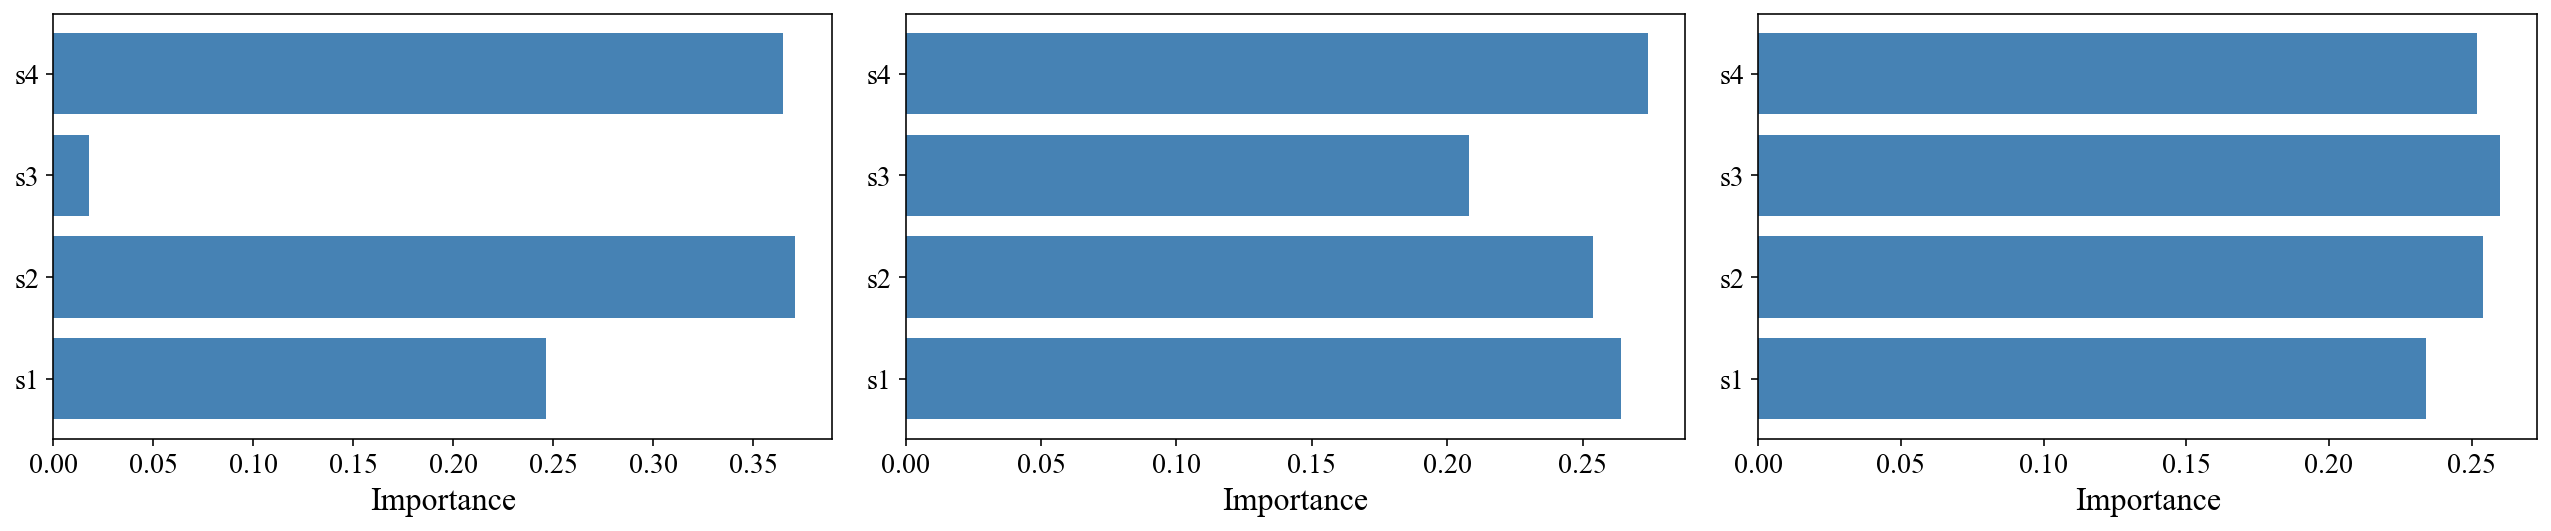

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, model in zip(axes, [rf_attack, rf_point, rf_antenna]):
    importances = model.feature_importances_
    ax.barh(features, importances, color="#4682B4")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 7. Inference

In [ ]:
# === Cell: Inference (Prediction) ===

def predict(s1, s2, s3, s4):
    """
    Predict attack status from 4 sensor RSSI values.
    
    Returns dict with:
      - attack: bool
      - point:  int (1-8) or None
      - antenna: str or None
      - confidence: dict with probabilities
    """
    X_input = pd.DataFrame([[s1, s2, s3, s4]], columns=features)
    
    # Step 1: Attack detection
    attack_prob = rf_attack.predict_proba(X_input)[0]
    is_attack = rf_attack.predict(X_input)[0] == 1
    
    result = {
        "attack": is_attack,
        "attack_confidence": f"{attack_prob[1] * 100:.1f}%",
        "point": None,
        "point_confidence": None,
        "antenna": None,
        "antenna_confidence": None,
    }
    
    if not is_attack:
        print(f"✅ No attack detected (confidence: {attack_prob[0] * 100:.1f}%)")
        return result
    
    # Step 2: Point prediction
    point = rf_point.predict(X_input)[0]
    point_prob = rf_point.predict_proba(X_input)[0]
    point_conf = point_prob.max() * 100
    
    # Step 3: Antenna prediction
    antenna_code = rf_antenna.predict(X_input)[0]
    antenna_name = ANTENNA_NAMES[antenna_code]
    antenna_prob = rf_antenna.predict_proba(X_input)[0]
    antenna_conf = antenna_prob.max() * 100
    
    result.update({
        "point": int(point),
        "point_confidence": f"{point_conf:.1f}%",
        "antenna": antenna_name,
        "antenna_confidence": f"{antenna_conf:.1f}%",
    })
    
    print(f"🚨 ATTACK DETECTED (confidence: {attack_prob[1] * 100:.1f}%)")
    print(f"   📍 Point: {point} (confidence: {point_conf:.1f}%)")
    print(f"   📡 Antenna: {antenna_name} (confidence: {antenna_conf:.1f}%)")
    
    return result


# --- Test ---
print("=== Test: baseline signal ===")
predict(-55, -54, -57, -59)

print("\n=== Test: attack signal ===")
predict(-70, -69, -74, -77)

=== Test: baseline signal ===
✅ No attack detected (confidence: 100.0%)

=== Test: attack signal ===
🚨 ATTACK DETECTED (confidence: 100.0%)
   📍 Point: 2 (confidence: 83.5%)
   📡 Antenna: Alfa ARS-N05 (confidence: 78.0%)


{'attack': True,
 'attack_confidence': '100.0%',
 'point': 2,
 'point_confidence': '83.5%',
 'antenna': 'Alfa ARS-N05',
 'antenna_confidence': '78.0%'}